# Practice 3

## Robust Linear Regression

### Objective of the Practical

This practical focuses on data regression methods. The primary objective is to implement and analyze methods for **robust linear regression**. We aim to model the relationship between two continuous variables: a predictor variable ($x$) and a response variable ($y$), by fitting a line to a set of data points.

The entire fitting process is treated as an **unconstrained optimization problem**. We will implement the **gradient descent** algorithm to find the optimal line parameters ($w_0$ and $w_1$) that minimize a chosen error function.

### What We Want to Demonstrate

The main goal is to practically explore the concept of **robustness against outliers**.

1.  **Expose the Problem:** We will first implement the standard **Least Squares Method (LSM)**. We want to *see* and *demonstrate* how this method is highly **sensitive to outliers**. Because LSM minimizes the *square* of the residuals ($e_i^2$) , data points that are "far away" (outliers) will have a very large error, which disproportionately dominates the minimization process and "pulls" the fitted line away from the true trend.

2.  **Implement the Solution:** To address this sensitivity, we will then explore a **robust error function**. Specifically, we will replace the quadratic error function of LSM with the **Cauchy function**:

    $$\rho(u)=\frac{c^{2}}{2}\log[1+(\frac{u}{c})^{2}]$$
    
3.  **Compare and Conclude:** The central experiment of this practical is to **compare the results** of the LSM and the robust Cauchy method. We will compare their performance on a "clean" dataset (no outliers) and, more importantly, on a dataset where we have intentionally added one or more outliers.

Ultimately, we want to *see* that the Cauchy function is less sensitive to these outliers, providing a more reliable and "robust" fit that better captures the underlying structure of the inlier data. We will also investigate how the parameter $c$ of the Cauchy function controls this robustness, effectively defining what the model considers an "inlier" versus an "outlier".


---

## Codebook


### `generate_points`

Generates 2D points from a multivariate normal distribution.

The covariance matrix is constructed from a rotation matrix (defined by `angle_deg`) and a scaling matrix (`lamb`) to control the elliptical shape and orientation of the data cloud.

**Parameters:**
* **`mean`** (list or np.ndarray, optional): The `[x, y]` mean (center) of the distribution. Default is `[0, 0]`.
* **`angle_deg`** (float, optional): The rotation angle of the data cloud in degrees. Default is 45.
* **`lamb`** (np.ndarray, optional): A 2x2 scaling matrix (eigenvalues). Default is `[[100, 0], [0, 1]]`.
* **`n`** (int, optional): Number of points to generate. Default is 100.
* **`seed`** (int, optional): A random seed for reproducibility. Default is `None`.

**Returns:**
* **`np.ndarray`**: An `(n, 2)` array of `[x, y]` data points.


### `plot_regression`

Plots data points, the fitted regression line, and optionally highlights outliers.

**Parameters:**
* **`points`** (np.ndarray): An `(n, 2)` array of `[x, y]` data points.
* **`w`** (tuple or list): The parameters `(w0, w1)` of the regression line ($y = w_0x + w_1$).
* **`outliers`** (list of int, optional): A list of indices corresponding to the `points` array that should be highlighted as outliers. Default is `None`.
* **`title`** (str, optional): The title for the plot. Default is "Linear Regression Fit".

**Returns:**
* **`None`**: Displays a matplotlib plot.



### `gradient_descent`

Performs gradient descent to find optimal `(w0, w1)` parameters.

This function minimizes the sum of a generic robust error function $\rho(e_i)$, where the residual $e_i = (w_0 x_i + w_1) - y_i$. The gradients are $\frac{\partial Q}{\partial w_{0}}=\sum \rho'(e_i) x_{i}$ and $\frac{\partial Q}{\partial w_{1}}=\sum \rho'(e_i)$. This is a generic implementation of the method described in the practical.

By default (with $\rho(u)=0.5u^2$), this function performs the standard **Least Squares Method (LSM)**.

**Parameters:**
* **`points`** (np.ndarray): An `(n, 2)` array of `[x, y]` data points.
* **`rho`** (callable, optional): The error function $\rho(u)$. Default is the LSM (quadratic) error.
* **`rho_prime`** (callable, optional): The derivative of the error function, $\rho'(u)$. Default is the LSM derivative (identity).
* **`alpha`** (float, optional): The learning rate (step size) for gradient descent. Default is `1e-4`.
* **`max_iter`** (int, optional): The maximum number of iterations. Default is `10000`.
* **`tol`** (float, optional): The stopping tolerance. The algorithm stops if the norm of the gradient is less than this value. Default is `1e-6`.
* **`return_residuals`** (bool, optional): If `True`, returns the final computed residuals $\rho(e)$. Default is `False`.

**Returns:**
* **`tuple`**:
    * If `return_residuals` is `False`: `(w0, w1)`
    * If `return_residuals` is `True`: `(w0, w1, residuals)`



### `gradient_descent_robust`

Performs gradient descent using the robust **Cauchy error function**.

This is a wrapper for `gradient_descent` that pre-defines the error function $\rho(u)$ and its derivative $\rho'(u)$ according to the Cauchy function:
* $\rho(u) = \frac{c^2}{2} \log(1 + (\frac{u}{c})^2)$
* $\rho'(u) = \frac{u}{1 + (\frac{u}{c})^2}$

**Parameters:**
* **`points`** (np.ndarray): An `(n, 2)` array of `[x, y]` data points.
* **`c`** (float, optional): The robustness parameter of the Cauchy function. Default is `1`.
* **`alpha`** (float, optional): The learning rate, passed to `gradient_descent`. Default is `1e-4`.
* **`max_iter`** (int, optional): Max iterations, passed to `gradient_descent`. Default is `10000`.
* **`tol`** (float, optional): Stopping tolerance, passed to `gradient_descent`. Default is `1e-6`.
* **`return_residuals`** (bool, optional): Passed to `gradient_descent`. Default is `False`.

**Returns:**
* **`tuple`**: The optimized `(w0, w1)` parameters, and optionally residuals.



### `compare_regression_methods`

Compares Least Squares (LSM) vs. Cauchy Robust regression on one plot.

This function fits both models to the same dataset (`points`), prints their resulting `(w0, wL)` parameters, and generates a comparative plot.

**Parameters:**
* **`points`** (np.ndarray): An `(n, 2)` array of `[x, y]` data points.
* **`c`** (float, optional): The robustness parameter 'c' to use for the Cauchy fit. Default is `1`.
* **`title_suffix`** (str, optional): A suffix to append to the plot title for context (e.g., "(no outliers)", "(with 1 outlier)").

**Returns:**
* **`tuple`**: A tuple containing `(w_ls, w_cauchy)`, where each `w` is a `(w0, w1)` tuple from the respective fit.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math

### FUNCTIONS from CODEBOOK ###

# Here we implement those functions that we mention in our

def generate_points(mean=[0., 0.], angle_deg=45, lamb=np.array([[100, 0], [0, 1]]), n=100, seed=None):
    """
    Generate random 2D points with covariance structure defined by rotation and lambda matrix.
    """
    if seed is not None:
        np.random.seed(seed)

    angle = angle_deg * math.pi / 180
    rot = np.array([[math.cos(angle), -math.sin(angle)], 
                    [math.sin(angle),  math.cos(angle)]])
    s = np.matmul(rot, np.matmul(lamb, rot.T))
    points = np.random.multivariate_normal(mean, s, n)
    return points


def plot_regression(points, w, outliers=None, title="Linear Regression Fit"):
    """
    Plot dataset and regression line.
    
    points: Nx2 array of [x, y]
    w: tuple/list (w0, w1)
    outliers: list of indices to highlight
    """
    x = points[:, 0]
    y = points[:, 1]
    y_pred = w[0] * x + w[1]

    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, label='Data points', color='blue', alpha=0.7)

    # Highlight outliers if any
    if outliers is not None:
        plt.scatter(x[outliers], y[outliers], color='red', label='Outliers', s=80, marker='x')

    plt.plot(x, y_pred, color='orange', linewidth=2, label='Fitted line')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()


def gradient_descent(points, rho=lambda u: 0.5 * u**2, rho_prime=lambda u: u, 
                     alpha=1e-4, max_iter=10000, tol=1e-6, return_residuals=False):
    """
    Perform gradient descent to find w0, w1 minimizing sum of rho(e_i)
    where e_i = w0*x_i + w1 - y_i.

    Parameters:
    - rho, rho_prime: error function and its derivative
    - alpha: learning rate
    - tol: stopping threshold for gradient norm
    - return_residuals: if True, returns (w0, w1, residuals)
    """
    x = points[:, 0]
    y = points[:, 1]

    # Initialize parameters
    w0, w1 = 0.0, 0.0

    for i in range(max_iter):
        y_pred = w0 * x + w1
        e = y_pred - y

        # Compute gradients
        grad_w0 = np.sum(rho_prime(e) * x)
        grad_w1 = np.sum(rho_prime(e))

        grad_norm = np.sqrt(grad_w0**2 + grad_w1**2)
        if grad_norm < tol:
            break

        # Update parameters
        w0 -= alpha * grad_w0
        w1 -= alpha * grad_w1

    if return_residuals:
        return w0, w1, rho(e)  # include residuals
    else:
        return w0, w1


def gradient_descent_robust(points, c=1, alpha=1e-4, max_iter=10000, tol=1e-6, return_residuals=False):
    """
    Perform gradient descent using the Cauchy robust error function:
    rho(u) = (c^2 / 2) * log(1 + (u / c)^2)
    rho'(u) = u / (1 + (u / c)^2)
    """
    rho = lambda u: 0.5 * (c**2) * np.log(1 + (u / c)**2)
    rho_prime = lambda u: u / (1 + (u / c)**2)

    return gradient_descent(points, rho=rho, rho_prime=rho_prime,
                            alpha=alpha, max_iter=max_iter, tol=tol,
                            return_residuals=return_residuals)


def compare_regression_methods(points, c=1, title_suffix="(no outliers)"):
    """
    Compare Least Squares vs Cauchy Robust regression on the same dataset.
    Fits both models, prints parameters, and plots results.
    """
    # Fit both models
    w_ls = gradient_descent(points)
    w_cauchy = gradient_descent_robust(points, c=c)

    # Print parameters
    print(f"=== Regression Comparison {title_suffix} ===")
    print(f"Least Squares Fit: w0 = {w_ls[0]:.4f}, w1 = {w_ls[1]:.4f}")
    print(f"Cauchy Robust Fit (c={c}): w0 = {w_cauchy[0]:.4f}, w1 = {w_cauchy[1]:.4f}")

    # Plot comparison
    x = points[:, 0]
    y = points[:, 1]

    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, color='blue', alpha=0.6, label='Data points')

    # Compute predicted lines
    y_ls = w_ls[0] * x + w_ls[1]
    y_cauchy = w_cauchy[0] * x + w_cauchy[1]

    # Plot both
    plt.plot(x, y_ls, color='orange', linewidth=2, label='Least Squares Fit')
    plt.plot(x, y_cauchy, color='green', linewidth=2, linestyle='--', label=f'Cauchy Robust Fit (c={c})')

    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Linear Regression Comparison {title_suffix}')
    plt.legend()
    plt.grid(True)
    plt.show()

    return w_ls, w_cauchy


---

# Tasks to be Performed

## Part 1: Least Squares Method and Outlier Sensitivity

1.  **Implement the method proposed with gradient descent and backtracking (or a small constant $\alpha$ value). You may check your method with a randomly generated set of points. Compute the parameters associated to the model and draw the lines that is obtained with the set of points.**


First, we generate a random set of points using a multivariate normal distribution. We control the covariance matrix by setting a rotation angle and an eigenvalue matrix (lambda) to manage the data's dispersion. A `seed=42` is used throughout this process to ensure the results are reproducible.

Next, we implement the gradient descent method. The objective is to find the optimal parameters ($w_0$, $w_1$) for a line that best fits the data. We achieve this by minimizing the **Least Squares Error (LSE)** function, which sums the squared vertical distances between our approximated line and the actual observed points.

The following sections present the results obtained for the least squares line, optimizing the parameters using our gradient descent implementation. We will also plot the resulting fit of the line.

Furthermore, we will compute the parameters using the analytical solution for linear regression (e.g., via `scikit-learn`) on the same generated dataset. This allows us to verify that our gradient descent implementation converges to the correct optimal solution.

Least Squares Fit Parameters (gradient descens method):
w0 (slope): 0.9659664355531026
w1 (intercept): 0.07510702192147199
Least Squares Fit Parameters (theorical approach):
w0 (slope): 0.965966435335239
w1 (intercept): 0.07510703200578916


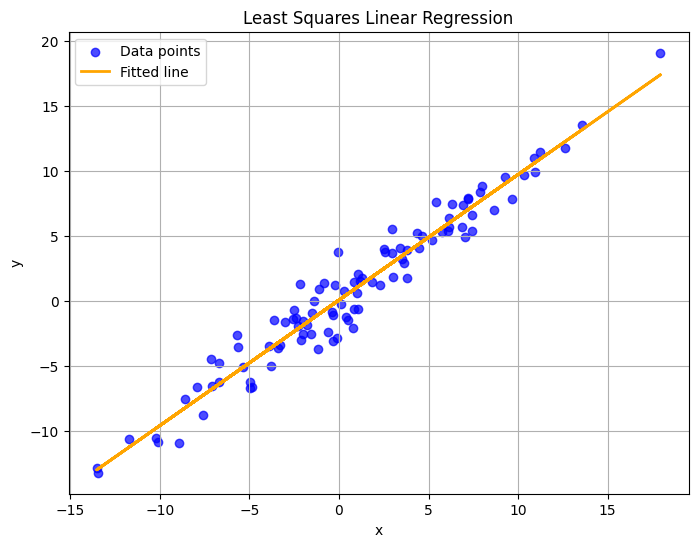

In [12]:
from sklearn.linear_model import LinearRegression

# Generate points
points = generate_points(angle_deg=45, seed=42)

# Least squares regression (rho(u) = 0.5*u^2)
w_ls = gradient_descent(points)

# LSR theorical
model = LinearRegression()

y = points[:, 1]
x_1d = points[:, 0]
X = x_1d.reshape(-1, 1)
model.fit(X, y)


print("Least Squares Fit Parameters (gradient descens method):")
print("w0 (slope):", w_ls[0])
print("w1 (intercept):", w_ls[1])

print("Least Squares Fit Parameters (theorical approach):")
print("w0 (slope):", model.coef_[0])
print("w1 (intercept):", model.intercept_)


# Plot result
plot_regression(points, w_ls, title="Least Squares Linear Regression")

We can see that the results obtained theoretically and those from the approximation using Newton's method are analogous. Furthermore, the fit of the resulting line, which minimizes the squared distance from the sample points to the regression line, is good. However, it must be taken into account that all these points seem to show homogeneous behavior between the two variables, indicating a fairly strong positive correlation. Moreover, there is no presence of values far from the average behavior of the point cloud (i.e., outliers) that could distort the behavior of the regression line.

---
2.  **Let us now check the sensitivity of the method to outliers, that is, points that do not follow the model. Using a set of points generate with an angle of 45 degrees, change the value of one point to a value "far away" from the set of points, for instance points `points[1]=[-40,20]`. Draw the line that approximates the set of points and observe that one point may have a large influence in the obtained solution.**

For instance, let's include an outlier in our generated dataset and see how the presence of this atypical point affects the estimation of the model's regression line.

Least Squares Fit Parameters:
w0 (slope): 0.5222779250220864
w1 (intercept): 0.8541772108284581


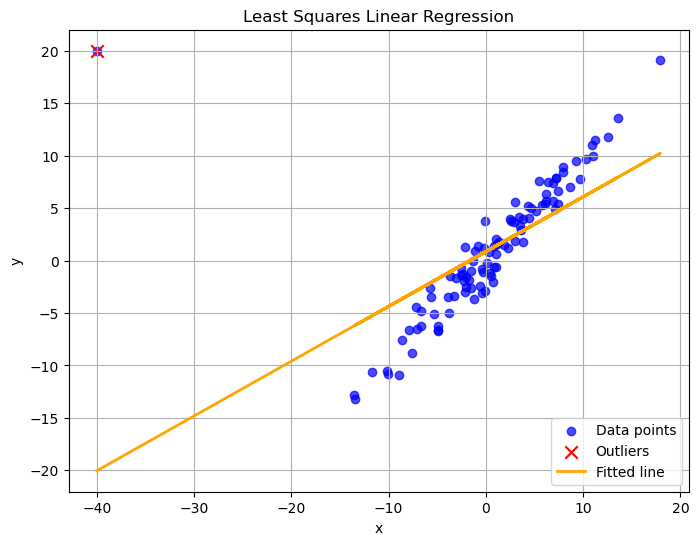

In [3]:
out_idx = 0
points[out_idx] = [-40, 20]
outliers = [out_idx]

# Least squares regression (rho(u) = 0.5*u^2)
w_ls = gradient_descent(points)

print("Least Squares Fit Parameters:")
print("w0 (slope):", w_ls[0])
print("w1 (intercept):", w_ls[1])

# Plot result
plot_regression(points, w_ls, title="Least Squares Linear Regression", outliers=outliers)

As observed in the plot above, the outlier manually introduced into our dataset as the point `[-40, 20]` does not behave like the rest of the generated data. One might expect that our generated model, which minimizes the squared distance from the point cloud to the line, would not be influenced by the behavior of atypical representations.

However, as can be seen in the obtained results, the LSE function is highly sensitive to the presence of atypical values. This causes the fit of the regression line to change completely, failing to capture the representativeness of the obtained sample. We can thus conclude that our linear regression model, using LSE as the minimization function, is truly sensitive to the presence of outliers.

---
3. Change now other points of the original dataset to assess the influence of outliers.

So, now we will introduce new outliers points to out dataset to assess the really influence of atypical values in the linear regression model with LSE function.

Least Squares Fit Parameters:
w0 (slope): 0.3566460548286093
w1 (intercept): 0.5058413764754423


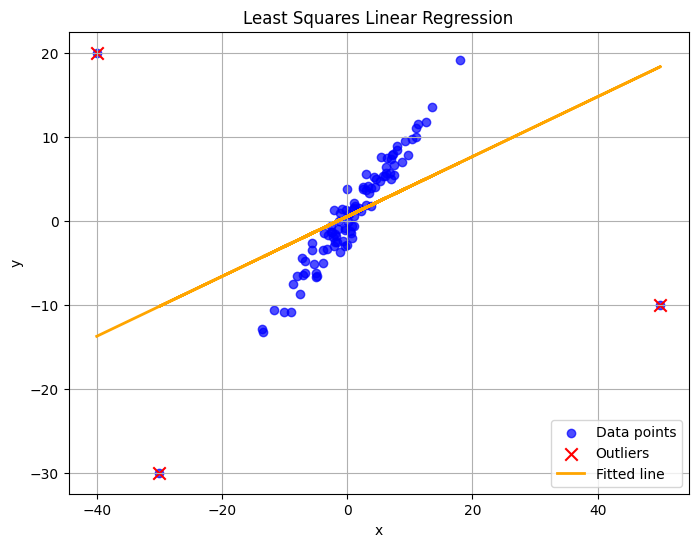

In [13]:
out_idx = [0, 5, 10]
points[out_idx] = np.array([
    [-40, 20],   # Nou valor per a l'índex 0
    [-30, -30],  # Nou valor per a l'índex 5
    [50, -10]    # Nou valor per a l'índex 10
])
outliers = out_idx


# Least squares regression (rho(u) = 0.5*u^2)
w_ls = gradient_descent(points)

print("Least Squares Fit Parameters:")
print("w0 (slope):", w_ls[0])
print("w1 (intercept):", w_ls[1])

# Plot result
plot_regression(points, w_ls, title="Least Squares Linear Regression", outliers=outliers)

## Part 2: Robust Functions (Cauchy Function)

For the following tasks, assume $c=1$ for the Cauchy function (you may use the set of points with a 45 degrees).

1.  **Plot the least squares function, $\rho(u)=\frac{1}{2}u^{2}$, and compare it with the Cauchy function, in order to see the "importance" given to each prediction error $u$, you may, for instance, plot the function $\rho(u)$ for $|u|\le 10$.**


Taking into account, the procced that we implement in the `gradient_descent` function with a generic loss function $\rho$, let  

$$
e_i = \hat{y}_i - y_i = w_0 x_i + w_1 - y_i, \qquad 
Q(w) = \sum_{i=1}^m \rho(e_i).
$$

When we have a general error function $\rho$, by the chain rule,  

$$
\frac{\partial Q}{\partial w_0} = \sum_{i=1}^m \rho'(e_i) \frac{\partial e_i}{\partial w_0}
= \sum_{i=1}^m \rho'(e_i)\,x_i,
$$

$$
\frac{\partial Q}{\partial w_1} = \sum_{i=1}^m \rho'(e_i) \frac{\partial e_i}{\partial w_1}
= \sum_{i=1}^m \rho'(e_i).
$$

So compactly, the gradient is  

$$
\nabla Q(w) =
\begin{pmatrix}
\sum_i \rho'(e_i)\,x_i \\[4pt]
\sum_i \rho'(e_i)
\end{pmatrix}.
$$

We apply this to use $\rho(u)=\frac{c^{2}}{2}\log\!\Big(1+\big(\tfrac{u}{c}\big)^{2}\Big)$ as our loss function (Cauchy function).

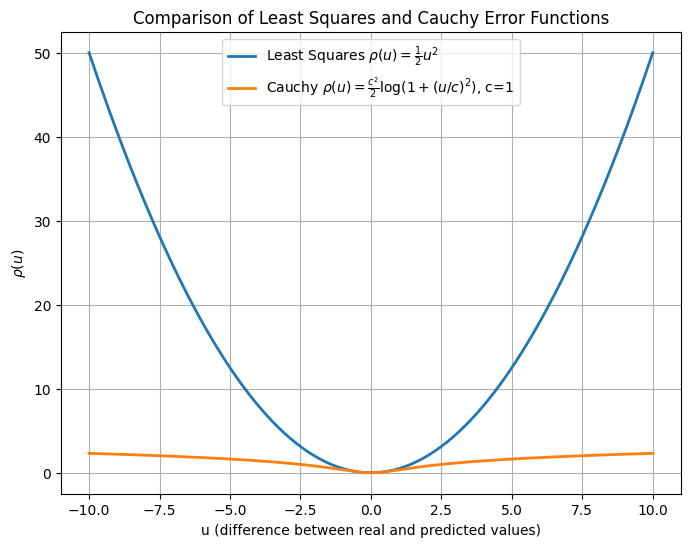

In [34]:
# Compare Least Squares vs Cauchy function
u = np.linspace(-10, 10, 400)
rho_ls = 0.5 * u**2
c = 1
rho_cauchy = 0.5 * (c**2) * np.log(1 + (u / c)**2)

plt.figure(figsize=(8, 6))
plt.plot(u, rho_ls, label=r'Least Squares $\rho(u) = \frac{1}{2}u^2$', linewidth=2)
plt.plot(u, rho_cauchy, label=r'Cauchy $\rho(u) = \frac{c^2}{2}\log(1+(u/c)^2)$, c=1', linewidth=2)
plt.xlabel('u (difference between real and predicted values)')
plt.ylabel(r'$\rho(u)$')
plt.title('Comparison of Least Squares and Cauchy Error Functions')
plt.legend()
plt.grid(True)
plt.show()

This graph is key to understanding the difference in robustness between the two error functions. The X-axis ($u$) represents the size of the error (the point's distance from the line), while the Y-axis ($\rho(u)$) represents the "cost" or "penalty" the model assigns to that error. We can see that the Least Squares (LSE) function (blue line) is a parabola, meaning its cost grows quadratically; a large error like $u=10$ has a high cost (50), giving outliers a disproportionate influence on the final result. In contrast, the Cauchy function (orange line) flattens out very quickly. For the same error $u=10$, the cost is minimal (around 2.5) and barely increases for larger errors. This demonstrates that the Cauchy function assigns a limited penalty to large errors, effectively "ignoring" outliers and making the fit much more robust.

---

2 & 3.  **Implement the algorithm that allows to compute the parameters $w_{0}$ and $w_{1}$ using the Cauchy function. For that issue you can use the backtracking gradient descent method (there is no need to use the Newton method). Compare the results obtained with the least squares function and with the Cauchy function, assuming that there are no outliers in the dataset.**

=== Regression Comparison (clean dataset) ===
Least Squares Fit: w0 = 0.9851, w1 = 0.2005
Cauchy Robust Fit (c=1): w0 = 0.9856, w1 = 0.2519


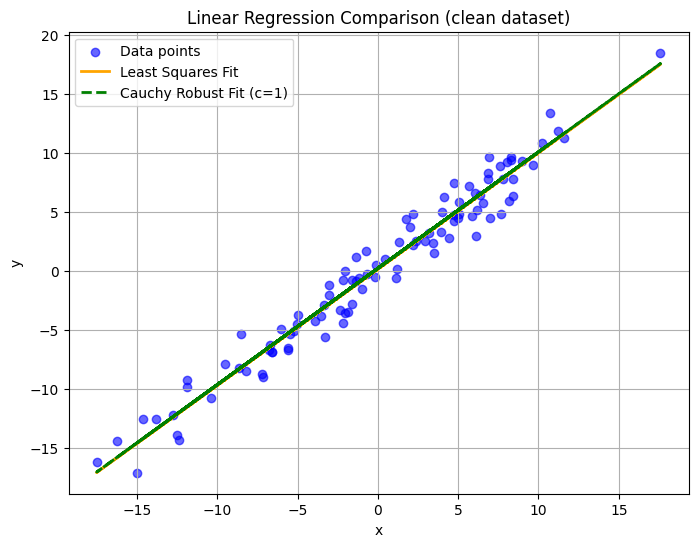

In [35]:
# Generate new clean dataset
points = generate_points(angle_deg=45, seed=0)


# Compare Least Squares and Cauchy Robust regression
w_ls, w_cauchy = compare_regression_methods(points, c=1, title_suffix="(clean dataset)")

We can see that the predictions are very similar. The lines are barely recognisable in the image.

---
4.  **Compare now the results with only one outlier. You may proceed as previously proposed. The Cauchy function should be more robust than the quadratic function.**

=== Regression Comparison (clean dataset) ===
Least Squares Fit: w0 = 0.6338, w1 = 0.6620
Cauchy Robust Fit (c=1): w0 = 0.9873, w1 = 0.2453


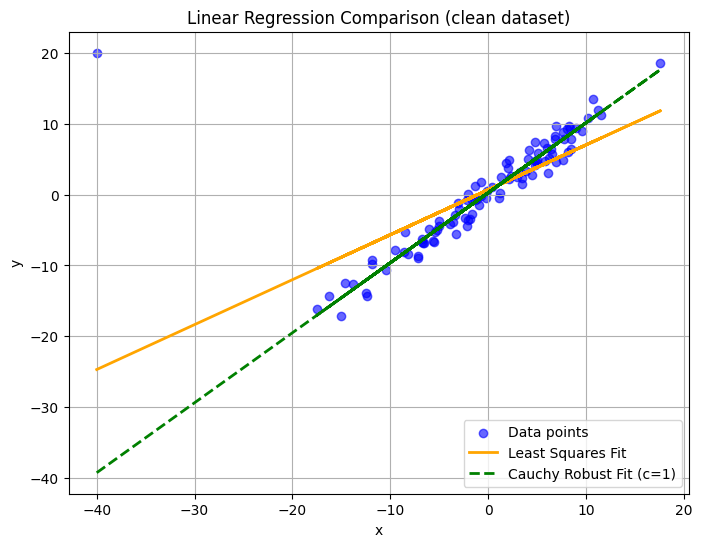

In [36]:
# Generate new clean dataset and perturbate it
points = generate_points(angle_deg=45, seed=0)
out_idx = 0
points[out_idx] = [-40, 20]
outliers = [out_idx]

# Compare Least Squares and Cauchy Robust regression
w_ls, w_cauchy = compare_regression_methods(points, c=1, title_suffix="(clean dataset)")

With one outlier, as we can see in the plot, the line generated by the Cauchy error function is very close to the previous line, but the line generated by Least Squares is strongly modified. The prediction of the Cauchy method seems much more reasonable in this case. 

---
5.  **Test the influence of the parameter $c$ in the parameters obtained. You may, for instance, check the results obtained with $c=1$, $c=100$, $c=1/100$ and $c=1/1000$. Can you reason why of these results? To this end, you are recommended to plot the histogram of the error function $u$ (its absolute value of $u$) and to compare with the shape corresponding $\rho(u)$ functions. Consider performing a "zoom" of the Cauchy function to see the interval at which the function behaves as a quadratic function. Which values are considered as "inliers" / "outliers"?**

Least Squares: w0 = 0.63380486988235 w1 = 0.6620055963742802


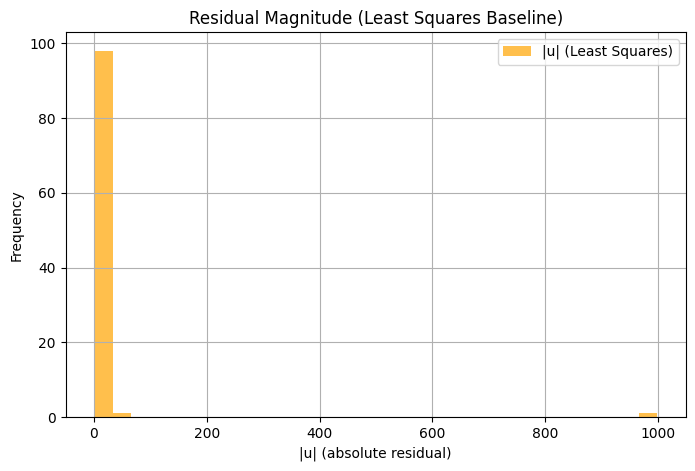

In [37]:
## EX 5 ##

# Generate new dataset and introduce one outlier
points = generate_points(angle_deg=45, seed=0)
points[0] = [-40, 20]  # strong outlier

# Compute least squares baseline
w_ls, w1, u_ls = gradient_descent(points, return_residuals=True)
print("Least Squares: w0 =", w_ls, "w1 =", w1)

# --- Plot Least Squares histogram once (baseline) ---
plt.figure(figsize=(8, 5))
plt.hist(np.abs(u_ls), bins=30, alpha=0.7, color='orange', label='|u| (Least Squares)')
plt.xlabel('|u| (absolute residual)')
plt.ylabel('Frequency')
plt.title('Residual Magnitude (Least Squares Baseline)')
plt.legend()
plt.grid(True)
plt.show()



This histogram displays the distribution of absolute residuals ($|u|$) from the "Least Squares Baseline" model. The X-axis represents the magnitude of the error (the absolute difference between a point's real value and the line's predicted value), while the Y-axis shows the frequency, or count, of points for each error magnitude.

The plot clearly reveals two distinct populations of data points, which are widely separated. On the far left, a very tall bar shows a high frequency (nearly 100) of points clustered at a very small absolute residual, close to zero. This group represents the inliers, or the main trend of the data, which the model fits relatively well.

In stark contrast, a single, isolated bar is visible on the far right of the graph, at an error magnitude of approximately 1000. This bar has a frequency of 1, indicating it represents a single data point. This is the outlier. The model fails to capture this point, resulting in an enormous residual. This histogram provides a clear visual diagnostic of the data's composition, separating the 99% of "normal" data from the 1% "atypical" data.

Now, we're going to analyses de behaivor of Cauchy function fit in linear regression for test the influence of the parameter $c$ in the parameters obtained:

Cauchy Robust (c=1): w0 = 0.9872955438750038, w1 = 0.2452815255836173


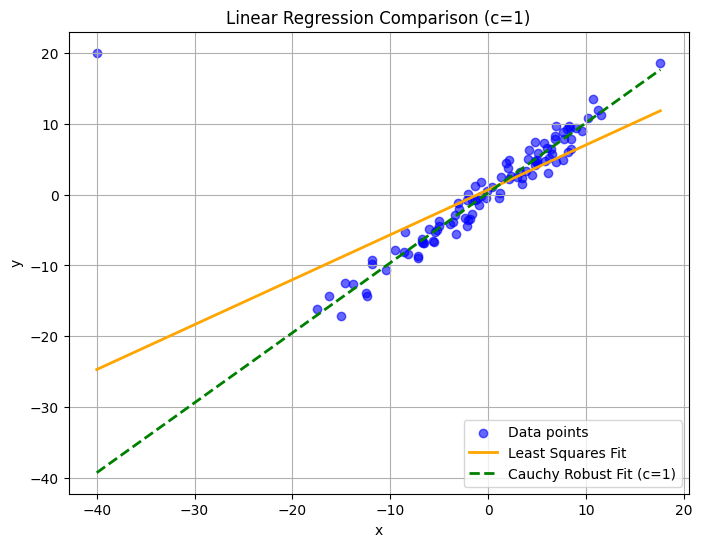

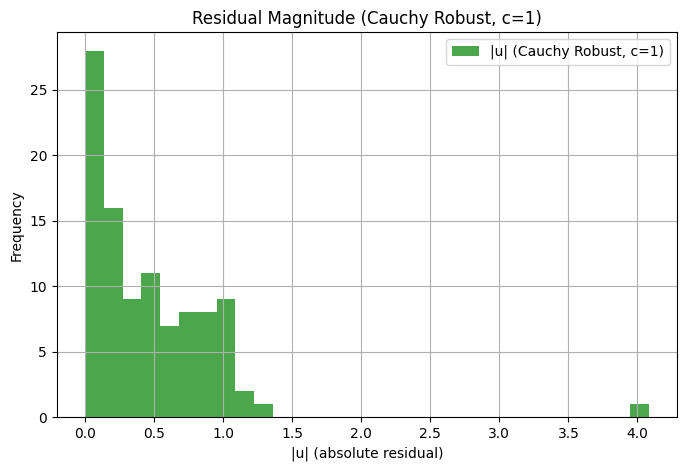

Cauchy Robust (c=100): w0 = 0.6830952584784602, w1 = 0.5972675080762282


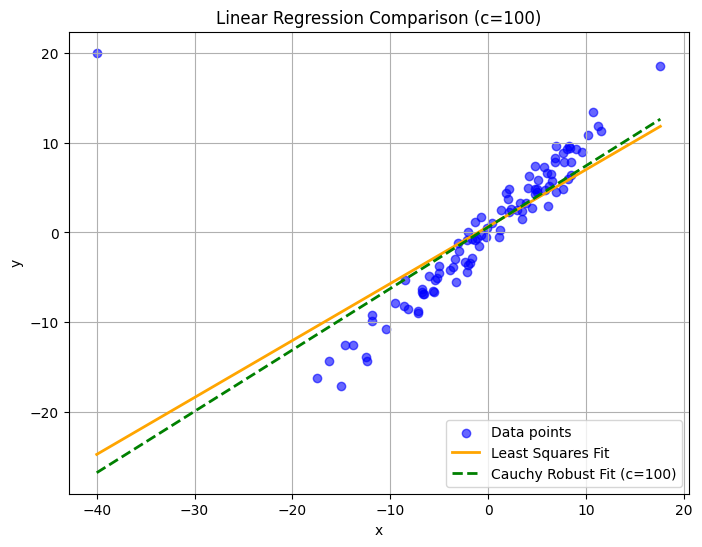

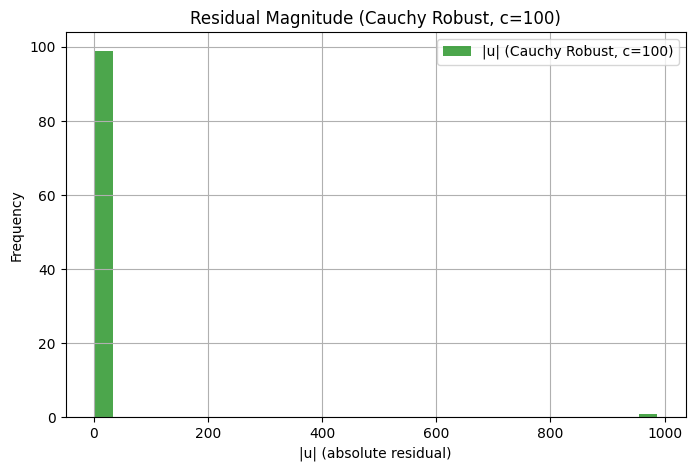

Cauchy Robust (c=0.01): w0 = 0.00026639335290217175, w1 = 0.004465373627183571


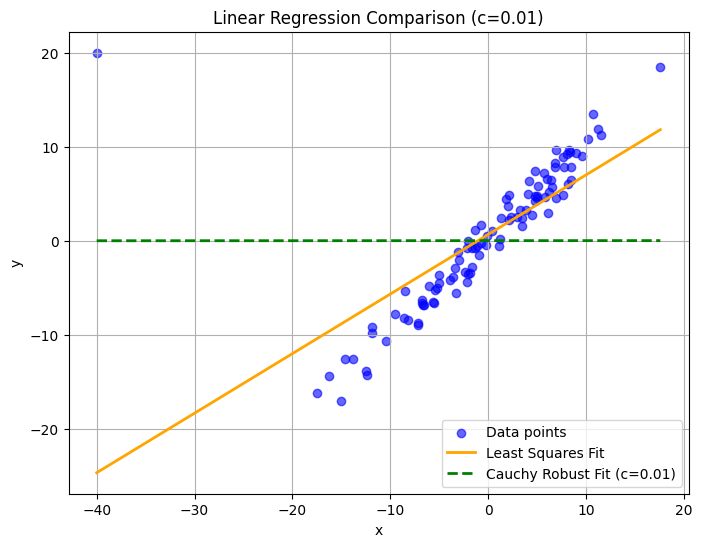

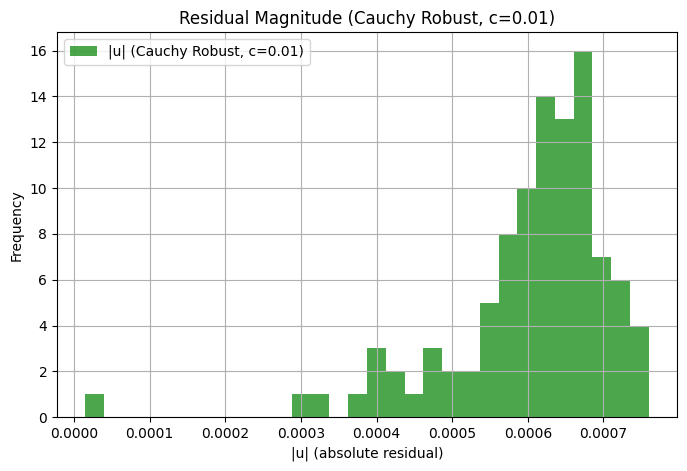

Cauchy Robust (c=0.001): w0 = -0.00011072281570223083, w1 = 9.990916911992692e-05


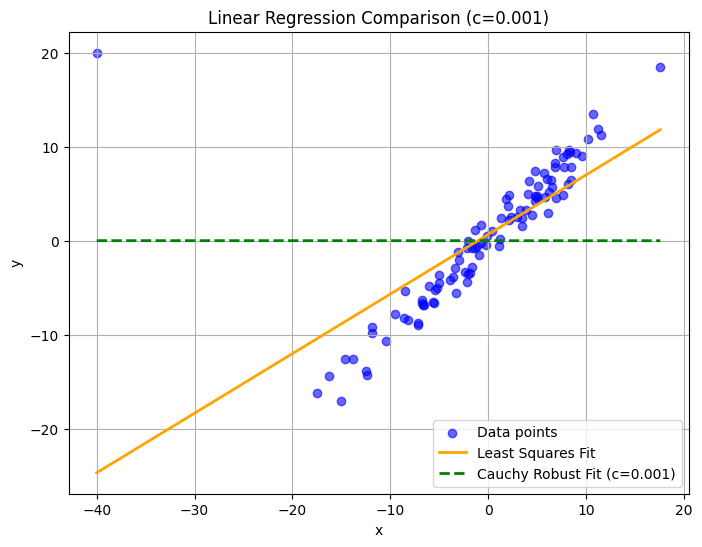

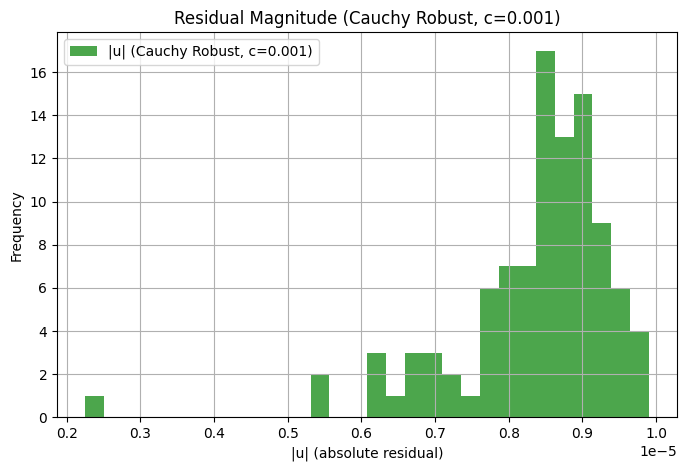

In [61]:
# Try several Cauchy parameter values
c_values = [1, 100, 1/100, 1/1000]

for c in c_values:    
    # Compute robust regression and residuals
    w_c, w2, u_cauchy = gradient_descent_robust(points, c=c, return_residuals=True)
    print(f"Cauchy Robust (c={c}): w0 = {w_c}, w1 = {w2}")

    # --- Plot regression lines comparison ---
    x = points[:, 0]
    y = points[:, 1]
    sort_idx = np.argsort(x)
    x_sorted = x[sort_idx]

    y_ls = w_ls * x_sorted + w1
    y_cauchy = w_c * x_sorted + w2

    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, color='blue', alpha=0.6, label='Data points')
    plt.plot(x_sorted, y_ls, color='orange', linewidth=2, label='Least Squares Fit')
    plt.plot(x_sorted, y_cauchy, color='green', linewidth=2, linestyle='--', label=f'Cauchy Robust Fit (c={c})')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Linear Regression Comparison (c={c})')
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Plot residual magnitude histogram for Cauchy ---
    plt.figure(figsize=(8, 5))
    plt.hist(np.abs(u_cauchy), bins=30, alpha=0.7, color='green', label=f'|u| (Cauchy Robust, c={c})')
    plt.xlabel('|u| (absolute residual)')
    plt.ylabel('Frequency')
    plt.title(f'Residual Magnitude (Cauchy Robust, c={c})')
    plt.legend()
    plt.grid(True)
    plt.show()

In this sense, the parameter $c$ in the Cauchy function $\rho(u)=\frac{c^{2}}{2}\log[1+(\frac{u}{c})^{2}]$ is a scale parameter that acts as a "soft" threshold. It behaves like the key to controlling the function's robustness. The parameter $c$ defines the boundary between what the model considers an "inlier" versus an "outlier." For residuals $u$ that are much smaller than $c$ ($|u| \ll c$), the Cauchy function behaves almost identically to the quadratic LSE function ($\rho(u) \approx \frac{1}{2}u^2$). These points are treated as inliers. For residuals $u$ that are much larger than $c$ ($|u| \gg c$), the function's cost "saturates" and grows very slowly (logarithmically). These points are "down-weighted" and treated as outliers, having minimal influence on the final fit. The challenge is to pick a $c$ that is larger than the typical inlier residuals but smaller than the outlier residuals.

With a large $c$, such as $c=100$ as this case, the "Cauchy Robust Fit" (green dashed line) is almost identical to the "Least Squares Fit" (orange line). Both lines are severely pulled by the outlier, and the residual histogram is nearly identical to the LSE baseline, showing $99$ inliers and one outlier with a massive residual. This is because the "inlier" (quadratic-like) region is extremely wide. All of our data points, including the outlier, have residuals smaller than this threshold, so the model treats all points as inliers. The Cauchy function provides no robustness and converges to the same non-robust LSE solution.

With a well-tuned $c$ like $c=1$, we see a successful robust fit. The Cauchy line (green) ignores the outlier and provides a much better fit to the main data cloud. The residual histogram shows: the $c=1$ threshold has successfully separated the data. The inliers (99 points) are clustered in the $|u| < 1.5$ range, while the outlier is clearly separated with a residual around $4.0$. The model's threshold sees the inliers as falling *within* its quadratic region but sees the outlier as falling far *outside* it. The model therefore down-weights the outlier's influence and focuses on the inliers.

With a small $c$ such as $c=0.01$ and $c=0.001$, we have the opposite problem. The Cauchy fit (green) has become a flat horizontal line near $y=0$, ignoring both the outlier and all the inlier data. The "inlier" quadratic region is now tiny (e.g., $-0.01$ to $0.01$). The actual inlier residuals (which we know are $\sim 0.5-1.5$) are now all considered massive outliers. The model effectively treats all 100 points as outliers and "rejects" them all. With no data left to fit, the algorithm converges to a trivial solution (like $w_0=0, w_1=0$). This is overly robust to the point of being useless.

For analyses better this situacions, now we going to plot the histogram of the error function $u$ (its absolute value of $u$) and to compare with the shape corresponding $\rho(u)$ functions, also consider performing a "zoom" of the Cauchy function to see the interval at which the function behaves as a quadratic function, like the quadratic LSE function.

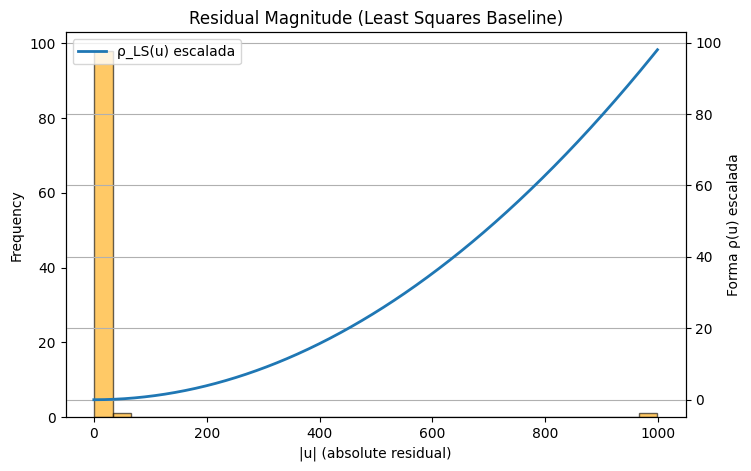

In [62]:
# --- Pèrdues i pesos ---
def rho_ls(x):
    return 0.5 * x**2

def rho_cauchy(x, c):
    return 0.5 * c**2 * np.log(1.0 + (x/c)**2)

def weight_cauchy(x, c):
    return 1.0 / (1.0 + (x/c)**2)

# --- (Opcional) Superposar ρ sobre l’histograma LS baseline ---
abs_u_ls = np.abs(u_ls)
grid = np.linspace(0, max(np.percentile(abs_u_ls, 99.5), abs_u_ls.max()), 1000)

plt.figure(figsize=(8,5))
counts, bins, _ = plt.hist(abs_u_ls, bins=30, alpha=0.6, edgecolor='k', label='|u| (LS)', color='orange')
plt.xlabel('|u| (absolute residual)')
plt.ylabel('Frequency')
plt.title('Residual Magnitude (Least Squares Baseline)')

# Escalat de ρ per comparar "forma" amb l’alçada de l’histograma
scale = counts.max() if counts.size else 1.0
rho_ls_scaled = rho_ls(grid)
rho_ls_scaled = rho_ls_scaled / rho_ls_scaled.max() * scale
ax2 = plt.gca().twinx()
ax2.plot(grid, rho_ls_scaled, lw=2, label='ρ_LS(u) escalada')
ax2.set_ylabel('Forma ρ(u) escalada')
ax2.legend(loc='upper right')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

As we saw in the other graf, the histogram concentrates almost all mass in the first few bins near zero, with a single distant bar around $|u|\approx10^3$ that reveals an extreme outlier. This configuration is characteristic of least squares under contamination: the bulk of points produce small residuals, but a very long right tail appears because the quadratic fit is pulled toward the aberrant observation, inflating the range of $|u|$.

The superposed scaled quadratic loss $\rho_{LS}(u)= \dfrac{1}{2}u^2$ rises smoothly and steeply across the x-axis, illustrating how the penalty accelerates with residual magnitude. Because a single outlier sits far from the origin, the horizontal scale expands to accommodate it, visually compressing the core of the histogram near zero. The combination of a heavy tail and a rapidly increasing quadratic penalty underscores the high leverage of extreme residuals under LS and motivates a robust alternative: within the dense central region LS and any robust loss coincide, but in the tail a sub-quadratic loss would attenuate the influence of the $|u|\approx10^3$ point and yield a fit more representative of the main data cloud. A focused zoom around the origin would further show that local behavior is effectively quadratic for inliers, while the practical distinction arises exclusively in the tails.

Cauchy Robust (c=1): w0 = 0.9872955438750038, w1 = 0.2452815255836173


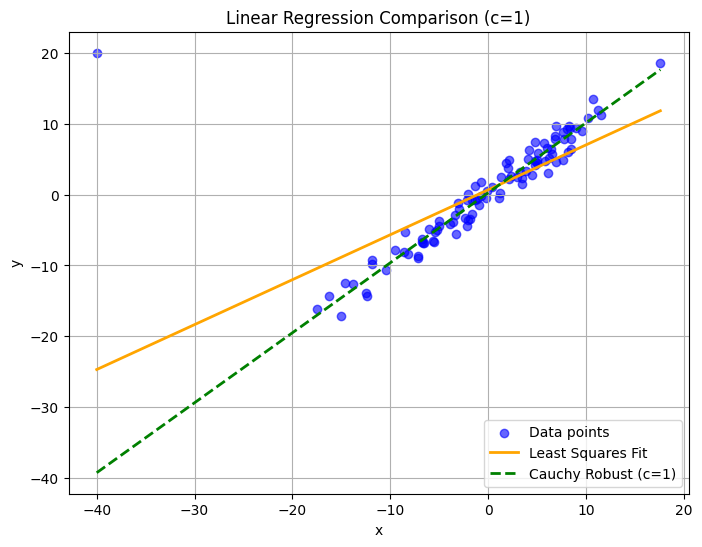

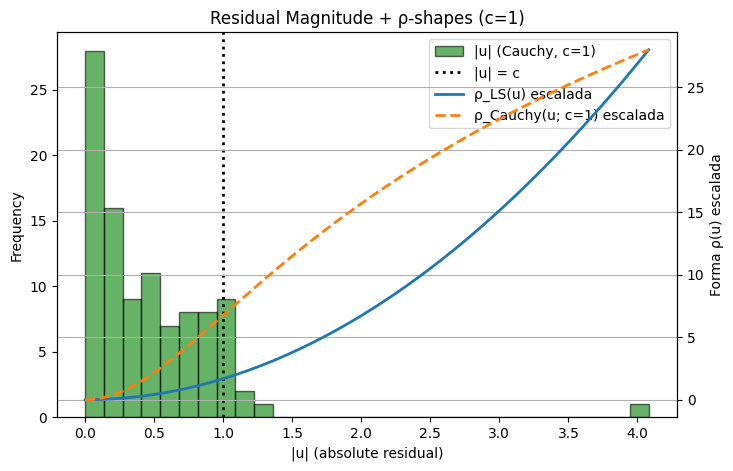

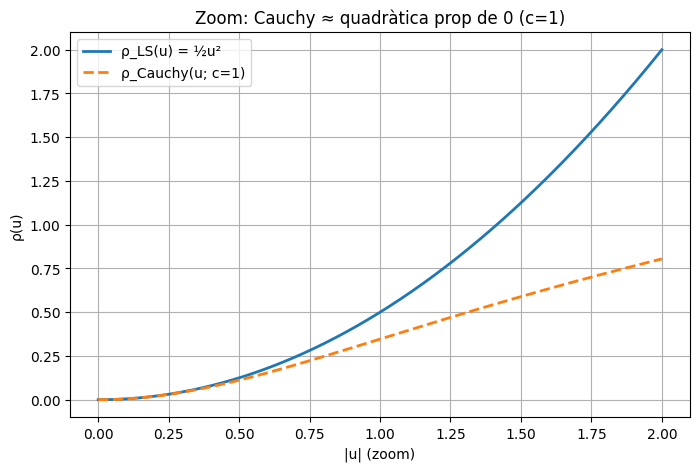

c=1: llindar inlier ≈ |u|≤1 → 92.0% de punts considerats inliers (w(u)>0.5).


In [63]:

# --- Bucle pels diferents c (Cauchy) ---
c_values = [1, 100, 1/100, 1/1000]
x = points[:, 0]
y = points[:, 1]
sort_idx = np.argsort(x)
x_sorted = x[sort_idx]
y_ls = w_ls * x_sorted + w1

def examinacio(c):
    w_c, w2, u_cauchy = gradient_descent_robust(points, c=c, return_residuals=True)
    print(f"Cauchy Robust (c={c}): w0 = {w_c}, w1 = {w2}")

    # --- Línies d’ajust ---
    y_cauchy = w_c * x_sorted + w2
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, color='blue', alpha=0.6, label='Data points')
    plt.plot(x_sorted, y_ls, color='orange', linewidth=2, label='Least Squares Fit')
    plt.plot(x_sorted, y_cauchy, color='green', linewidth=2, linestyle='--', label=f'Cauchy Robust (c={c})')
    plt.xlabel('x'); plt.ylabel('y'); plt.title(f'Linear Regression Comparison (c={c})')
    plt.legend(); plt.grid(True); plt.show()

    # --- Histograma |u| + formes ρ escalades (LS i Cauchy) ---
    abs_u_c = np.abs(u_cauchy)
    grid = np.linspace(0, max(np.percentile(abs_u_c, 99.5), abs_u_c.max()), 1000)

    fig, ax1 = plt.subplots(figsize=(8,5))
    counts, bins, _ = ax1.hist(abs_u_c, bins=30, alpha=0.6, edgecolor='k',
                               label=f'|u| (Cauchy, c={c})', color='green')
    ax1.set_xlabel('|u| (absolute residual)')
    ax1.set_ylabel('Frequency')
    ax1.set_title(f'Residual Magnitude + ρ-shapes (c={c})')
    ax1.axvline(c, ls=':', lw=2, color='k', label='|u| = c')  # llindar inlier práctico

    scale = counts.max() if counts.size else 1.0
    ax2 = ax1.twinx()
    # ρ_LS escalada
    rls = rho_ls(grid); rls = rls / (rls.max() if rls.max()>0 else 1.0) * scale
    ax2.plot(grid, rls, lw=2, label='ρ_LS(u) escalada')

    # ρ_Cauchy escalada
    rc = rho_cauchy(grid, c); rc = rc / (rc.max() if rc.max()>0 else 1.0) * scale
    ax2.plot(grid, rc, lw=2, ls='--', label=f'ρ_Cauchy(u; c={c}) escalada')
    ax2.set_ylabel('Forma ρ(u) escalada')

    # Llegendes
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1+h2, l1+l2, loc='upper right')
    plt.grid(True); plt.show()

    # --- "Zoom" on Cauchy ≈ quadràtica: |u| ≤ ~2c ---
    win = max(1e-8, 2*c)
    z = np.linspace(0, win, 600)
    plt.figure(figsize=(8,5))
    plt.plot(z, rho_ls(z), lw=2, label='ρ_LS(u) = ½u²')
    plt.plot(z, rho_cauchy(z, c), '--', lw=2, label=f'ρ_Cauchy(u; c={c})')
    plt.xlabel('|u| (zoom)'); plt.ylabel('ρ(u)')
    plt.title(f'Zoom: Cauchy ≈ quadràtica prop de 0 (c={c})')
    plt.legend(); plt.grid(True); plt.show()

    # --- Quantificar inliers (pes > 0.5 ↔ |u| ≤ c) ---
    frac_in = np.mean(abs_u_c <= c)
    print(f"c={c}: llindar inlier ≈ |u|≤{c} → {frac_in*100:.1f}% de punts considerats inliers (w(u)>0.5).")

examinacio(c=c_values[0])


The scatterplot with fitted lines indicates that the least-squares solution is visibly drawn toward the extreme point at the far left, whereas the Cauchy fit with $c=1$ aligns with the main linear trend determined by the dense central cloud. The robust line reduces leverage from the aberrant observation and produces a slope–intercept pair that is more representative of the bulk of the sample. The divergence between the two fits is therefore explained by the difference in tail penalization: quadratic loss magnifies the influence of large residuals, while the Cauchy loss downweights them.

The residual histogram for the Cauchy fit shows that the vast majority of absolute residuals lie below the vertical reference $|u|=c$, which corresponds to unit Cauchy weight exceeding one half. This implies that most observations act as effective inliers under the chosen tuning. Superposed, scaled loss shapes make clear that the quadratic penalty grows rapidly with $|u|$, while the Cauchy penalty flattens in the tail; consequently, observations beyond $|u|\approx1$ contribute far less to the objective under Cauchy than under least squares. The single bar in the far right tail is strongly attenuated, which explains the reduced displacement of the robust line relative to the LS line.

The zoomed loss curves around the origin confirm that, for $|u|<<c$, the Cauchy loss is locally quadratic and therefore coincides with least squares on small residuals. Hence, the two estimators treat the central portion of the residual distribution similarly; their practical discrepancy arises in the tails, where the sub-quadratic growth of the Cauchy loss mitigates the leverage of extreme deviations. With $c=1$ in this dataset, the tuning achieves a favorable balance: it preserves efficiency on inliers while sufficiently discounting the single extreme point to recover the dominant linear structure.



Cauchy Robust (c=100): w0 = 0.6830952584784602, w1 = 0.5972675080762282


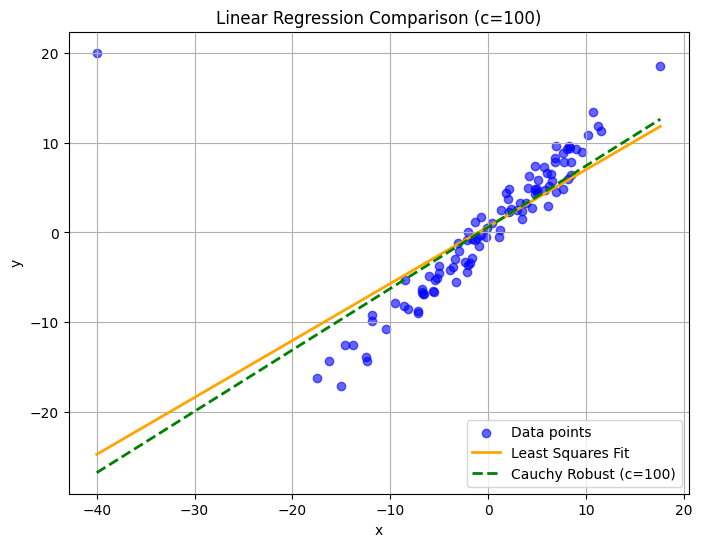

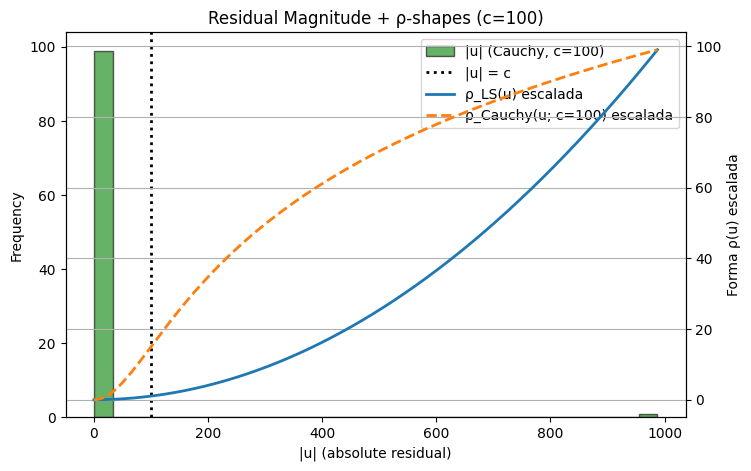

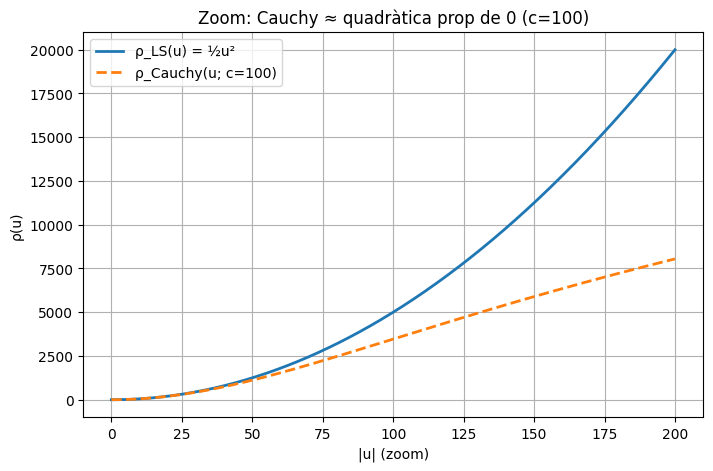

c=100: llindar inlier ≈ |u|≤100 → 99.0% de punts considerats inliers (w(u)>0.5).


In [45]:
examinacio(c=c_values[1])


The fitted lines are nearly coincident when $c=100$, indicating that the Cauchy estimator behaves almost like least squares for this tuning. Because the loss remains close to quadratic over the residual range occupied by the bulk of points, the extreme observation retains appreciable leverage and the robust solution differs only marginally from the LS line.

The residual histogram under the Cauchy fit places almost all mass well below the vertical reference at $|u|=c$, implying weights greater than one half for the vast majority of observations. In this regime the effective objective is dominated by the central residuals exactly as in least squares, while only the single very large residual near $|u|\approx10^3$ is substantially downweighted. The superposed loss shapes clarify this behavior: the quadratic penalty escalates rapidly, whereas the Cauchy penalty flattens only for $|u|>>c$; consequently, only the far–right-tail bar experiences meaningful attenuation, which is insufficient to reorient the fit away from the LS solution.

The local zoom corroborates that, for $|u|<<c$, the Cauchy loss is essentially quadratic and thus indistinguishable from least squares on small errors. With $c=100$, this quadratic neighborhood is wide enough to encompass the entire inlier cloud, so efficiency on the core is preserved while robustness benefits are limited to a mild reduction of the outlier’s influence. In datasets with sparse contamination of this magnitude, such a large c yields a near-LS estimator; stronger protection against leverage would require a smaller c calibrated to the transition between the histogram’s body and tail.

Cauchy Robust (c=0.01): w0 = 0.00026639335290217175, w1 = 0.004465373627183571


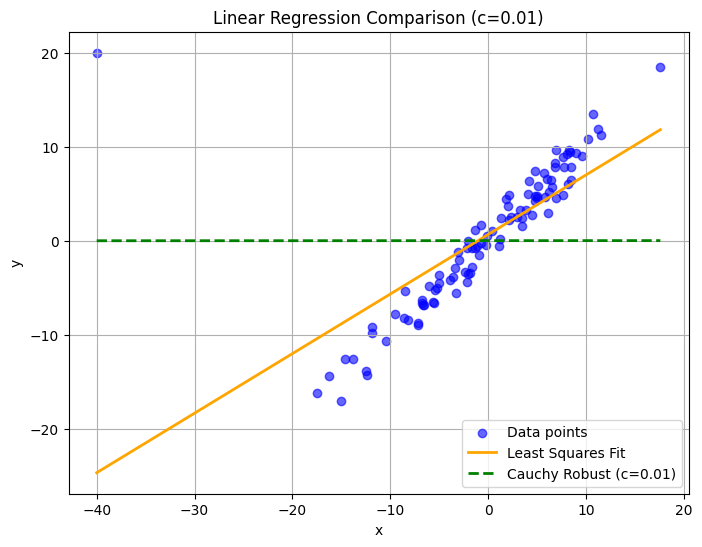

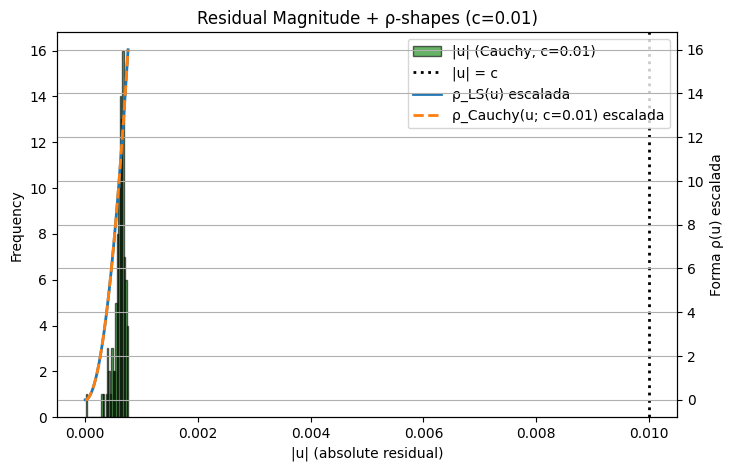

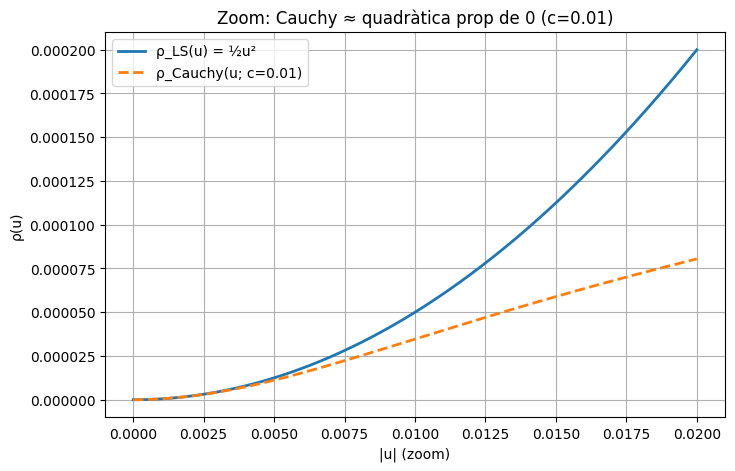

c=0.01: llindar inlier ≈ |u|≤0.01 → 100.0% de punts considerats inliers (w(u)>0.5).


In [47]:
examinacio(c=c_values[2])

With $c=0.01$ the Cauchy loss becomes extremely selective. The fitted robust line is essentially flat at $y\approx0$, indicating that the optimization has discounted the slope information carried by the cloud and converged to a degenerate solution in which most observations receive very small effective weight. This behavior is consistent with the heavy downweighting induced by a very small tuning constant: once $|u|$ is not much smaller than $c$, the objective becomes nearly flat in the tails and the gradient provides little guidance, so the estimator can underfit the signal.

The residual histogram reported for the Cauchy fit falls entirely to the left of the reference $|u|=c$, and the superposed loss shapes overlap closely near the origin. Interpreted literally, this suggests that, relative to the scale c, the residuals are treated as inliers and the loss behaves approximately quadratically; however, the near-horizontal fitted line shows that, in practice, the optimization did not exploit the linear structure of the data. The apparent contradiction points to a scale mismatch or numerical sensitivity: either the residuals have been computed on a different scale than that used for tuning, or the tiny value of c has rendered the objective too flat away from zero for the iterative scheme to recover the correct slope.

The local zoom confirms that, even for such a small c, Cauchy is only approximately quadratic in a very narrow neighborhood of the origin; beyond this neighborhood the penalty grows sub-quadratically and rapidly attenuates influence. In this configuration the method prioritizes minimizing a handful of near-zero residuals over representing the global linear trend, which explains the underfit. A principled choice of c should be commensurate with the typical residual scale of the problem; selecting c on the order of the transition between the body and the tail of the |u| histogram prevents the loss from becoming too flat and preserves identifiability of the slope while still mitigating the leverage of extreme deviations.

Cauchy Robust (c=0.001): w0 = -0.00011072281570223083, w1 = 9.990916911992692e-05


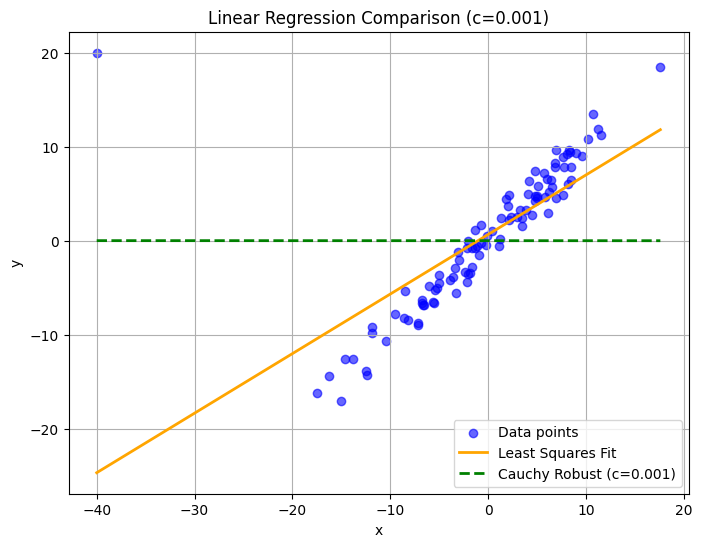

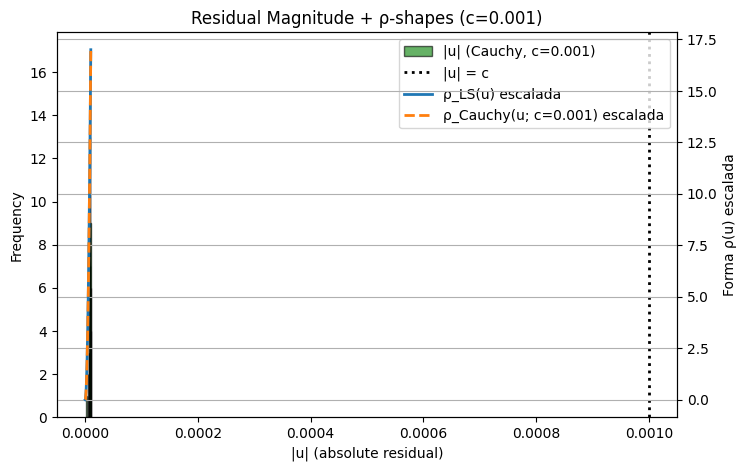

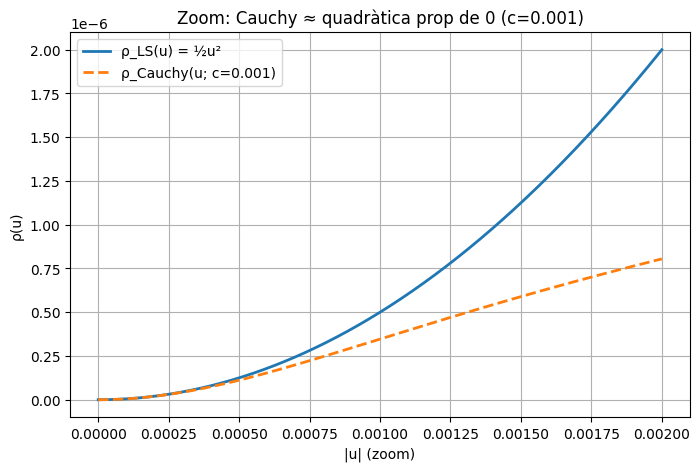

c=0.001: llindar inlier ≈ |u|≤0.001 → 100.0% de punts considerats inliers (w(u)>0.5).


In [48]:
examinacio(c=c_values[3])

With $c=0.001$ the Cauchy estimator becomes extremely conservative, effectively annihilating the slope information and yielding an almost horizontal fit near $y\approx0$. This outcome reflects the severe down-weighting induced by such a small tuning constant: once residual magnitudes are not far smaller than c, the objective is nearly flat in the tail and the gradient offers little directional signal, so the optimization underfits the linear trend despite the clear structure in the bulk of points.

The residual histogram lies entirely to the left of the reference $|u|=c$, and the scaled Cauchy and quadratic loss shapes overlap closely in the tiny neighborhood around zero. Interpreted relative to c, most observations behave as inliers with weights exceeding one half; however, on the absolute scale of the data this criterion is too strict, and the estimator discounts moderate, informative deviations to the point of collapsing the slope. The apparent consistency between “$|u|$≤c for most points” and the degenerate fit indicates a scale mismatch: the chosen c is orders of magnitude smaller than the typical residual scale implied by the data.

The zoomed loss curves confirm that Cauchy is only approximately quadratic in an exceedingly narrow band around the origin when c=0.001; beyond this band the penalty grows sub-quadratically and rapidly attenuates influence. In practice, a tuning parameter should be chosen on the order of the histogram’s body–tail transition so that the method preserves efficiency on genuine inliers while curbing the leverage of extremes. Increasing c by one or more orders of magnitude would restore identifiability of the slope while retaining meaningful robustness to outliers.


In summary, the combined evidence from the residual histograms, the superposed loss shapes, and the local quadratic zoom demonstrates that Cauchy preserves LS behavior for small errors while curbing the influence of extremes. Appropriate tuning of c delineates the inlier–outlier boundary and yields a fit that reflects the dominant linear structure without being dictated by isolated aberrant observations.

---

6.  **The Cauchy function is not "perfect", and it is not robust for any number of outliers. Using $c=1$ and $c=1/100$ you may, as before, gradually introduce more number of outliers into the dataset. You should see that for a certain number of outliers, the the Cauchy function will be sensitive to the "high" number of outliers. Can you comment on the experiments you have performed?**

In this exercice, we will explore that the Cauchy function is not at robust as we thought for any number of outliers. For this propuose, we will explore three differents types of noise, we will introduces them to our dataset and observe the behaivor of the Cauchy function in relation to the LS function when the number of atypical noise data increase.

Baseline (clean data) Least Squares: w0=0.985088, w1=0.200515

Cauchy parameter c = 1
Outliers =  5 | LS: w0=-0.048264, w1=2.422356, RMSE_all=11.5086, RMSE_inliers=7.7250
                 Cauchy(c=1): w0=0.976075, w1=0.266849, RMSE_all=15.5795, RMSE_inliers=1.4308
Outliers = 10 | LS: w0=-0.184857, w1=6.972475, RMSE_all=22.2965, RMSE_inliers=10.4593
                 Cauchy(c=1): w0=0.966501, w1=0.311112, RMSE_all=26.2646, RMSE_inliers=1.4539
Outliers = 20 | LS: w0=2.329492, w1=18.796196, RMSE_all=40.4610, RMSE_inliers=21.7739
                 Cauchy(c=1): w0=0.967321, w1=0.336609, RMSE_all=49.8626, RMSE_inliers=1.4424
Outliers = 40 | LS: w0=2.623263, w1=26.114045, RMSE_all=39.5331, RMSE_inliers=27.8740
                 Cauchy(c=1): w0=0.988226, w1=0.665308, RMSE_all=106.2516, RMSE_inliers=1.5057


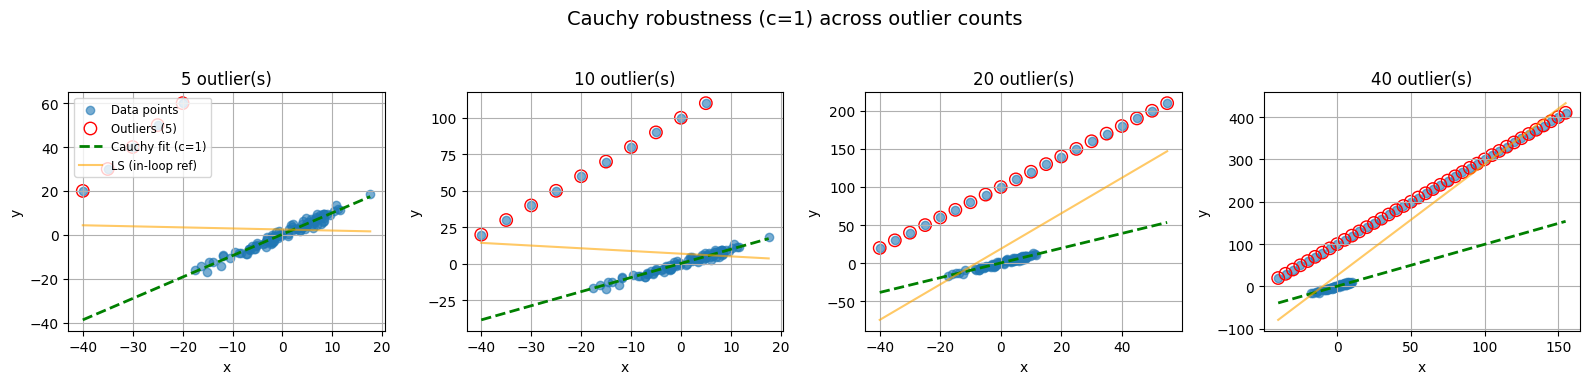

Cauchy parameter c = 0.01
Outliers =  5 | LS: w0=-0.048264, w1=2.422356, RMSE_all=11.5086, RMSE_inliers=7.7250
                 Cauchy(c=0.01): w0=-0.000145, w1=0.004291, RMSE_all=11.7811, RMSE_inliers=7.1692
Outliers = 10 | LS: w0=-0.184857, w1=6.972475, RMSE_all=22.2965, RMSE_inliers=10.4593
                 Cauchy(c=0.01): w0=0.008970, w1=-0.000234, RMSE_all=23.5099, RMSE_inliers=7.1808
Outliers = 20 | LS: w0=2.329492, w1=18.796196, RMSE_all=40.4610, RMSE_inliers=21.7739
                 Cauchy(c=0.01): w0=0.008063, w1=0.000054, RMSE_all=57.7906, RMSE_inliers=6.8820
Outliers = 40 | LS: w0=2.623263, w1=26.114045, RMSE_all=39.5331, RMSE_inliers=27.8740
                 Cauchy(c=0.01): w0=0.006598, w1=0.000101, RMSE_all=154.1065, RMSE_inliers=6.9687


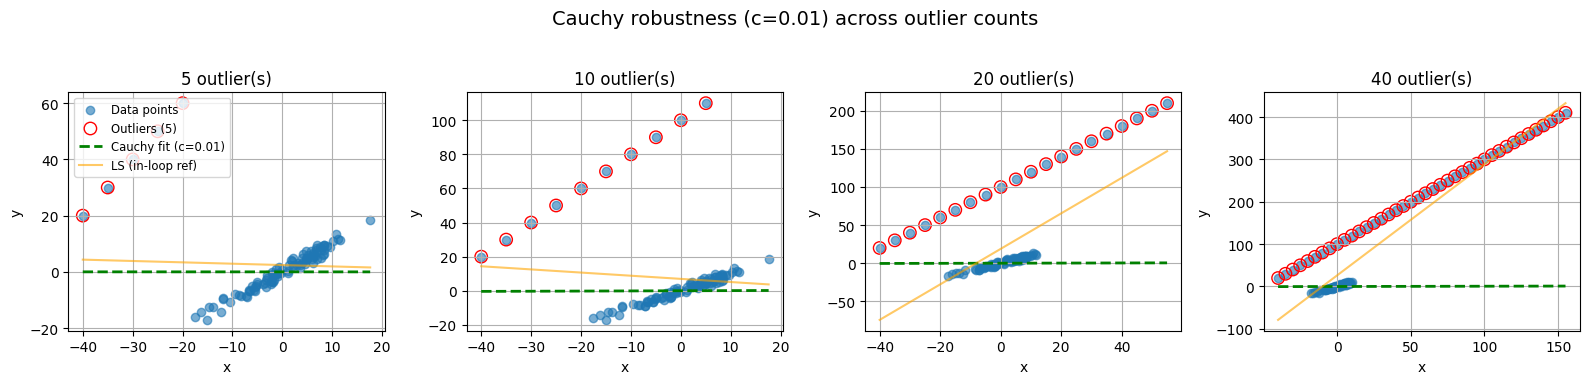

In [50]:
###  EX 6 TYPE OF NOISE 1 ###

import numpy as np
import matplotlib.pyplot as plt

def ls_closed_form(points):
    x = points[:,0].astype(float)
    y = points[:,1].astype(float)
    A = np.column_stack([x, np.ones_like(x)])
    beta, *_ = np.linalg.lstsq(A, y, rcond=None)
    w, b = beta
    u = y - (w*x + b)
    return w, b, u


def run_cauchy_outlier_experiment(
    outlier_counts=(5,10,20, 40), 
    c_values=(1, 1/100),
    n_points_display=50,
    outlier_offset_x=-40,
    outlier_offset_y=20,
    outlier_spacing=(5, 10)
):
    """
    For each c in c_values and each number of outliers in outlier_counts:
      - generate a fresh dataset (same seed for reproducibility)
      - replace the first n_outliers points with strong outliers
      - fit least-squares (baseline) and cauchy robust
      - plot fits and mark outliers
      - print w estimates and RMSE (all / inliers)
    """
    # helper to compute RMSE
    def rmse(y_true, y_pred):
        return np.sqrt(np.mean((y_true - y_pred)**2))

    # first compute LS baseline once on the original dataset with ONE outlier (or none) if you prefer:
    base_points = generate_points(angle_deg=45, seed=0)  # original clean dataset

    # We'll print a baseline LS fit on clean data (no outliers) for reference:
    w_ls_clean, b_ls_clean = gradient_descent(base_points, return_residuals=False)
    print("Baseline (clean data) Least Squares:", f"w0={w_ls_clean:.6f}, w1={b_ls_clean:.6f}\n")

    # Loop over c values
    for c in c_values:
        print("===============================")
        print(f"Cauchy parameter c = {c}")
        print("===============================")

        # Prepare a 2x(len(outlier_counts)) grid: left column fit plots, right column histograms optionally
        n_cases = len(outlier_counts)
        fig, axes = plt.subplots(1, n_cases, figsize=(4*n_cases, 4), squeeze=False)
        # We'll use a single row of subplots: each column shows data with Cauchy fit and marks outliers.
        for idx, n_outliers in enumerate(outlier_counts):
            # regenerate clean dataset for each case to keep comparisons fair
            points = generate_points(angle_deg=45, seed=0).copy()

            # specify outliers by overwriting the first n_outliers points
            for j in range(min(n_outliers, len(points))):
                dx = outlier_offset_x + j * outlier_spacing[0]
                dy = outlier_offset_y + j * outlier_spacing[1]
                points[j, 0] = dx
                points[j, 1] = dy

            # indices of outliers
            outlier_idx = np.arange(min(n_outliers, len(points)))

            # Fit LS and Cauchy robust
            w_ls, b_ls, u_ls = ls_closed_form(points)
            w_c, b_c, u_c = gradient_descent_robust(points, c=c, return_residuals=True)

            # compute predictions and RMSEs
            x = points[:, 0]
            y = points[:, 1]
            ypred_ls = w_ls * x + b_ls
            ypred_c = w_c * x + b_c

            rmse_all_ls = rmse(y, ypred_ls)
            rmse_all_c = rmse(y, ypred_c)

            # RMSE on inliers (exclude first n_outliers)
            if n_outliers < len(points):
                inlier_idx = np.arange(n_outliers, len(points))
                rmse_inliers_ls = rmse(y[inlier_idx], ypred_ls[inlier_idx])
                rmse_inliers_c = rmse(y[inlier_idx], ypred_c[inlier_idx])
            else:
                rmse_inliers_ls = np.nan
                rmse_inliers_c = np.nan

            # Print summary numbers
            print(f"Outliers = {n_outliers:2d} | LS: w0={w_ls:.6f}, w1={b_ls:.6f}, RMSE_all={rmse_all_ls:.4f}, RMSE_inliers={rmse_inliers_ls:.4f}")
            print(f"                 Cauchy(c={c}): w0={w_c:.6f}, w1={b_c:.6f}, RMSE_all={rmse_all_c:.4f}, RMSE_inliers={rmse_inliers_c:.4f}")

            # Plot: data points, outliers highlighted, and the Cauchy fit only (no LS comparison in-loop)
            ax = axes[0, idx]
            ax.scatter(x, y, color='tab:blue', alpha=0.6, label='Data points')
            if n_outliers > 0:
                ax.scatter(points[outlier_idx, 0], points[outlier_idx, 1], 
                           facecolors='none', edgecolors='red', s=80, label=f'Outliers ({n_outliers})')

            # plot Cauchy line (sorted for a smooth line)
            sort_idx = np.argsort(x)
            x_sorted = x[sort_idx]
            ax.plot(x_sorted, w_c * x_sorted + b_c, color='green', linewidth=2, linestyle='--', label=f'Cauchy fit (c={c})')

            # optionally plot LS baseline once on first panel as reference (comment/uncomment)
            if True:
                # show baseline LS on first panel if you like (comment out to keep no-LS in loop)
                ax.plot(x_sorted, w_ls * x_sorted + b_ls, color='orange', linewidth=1.5, alpha=0.6, label='LS (in-loop ref)')
            
            ax.set_title(f"{n_outliers} outlier(s)")
            ax.set_xlabel('x')
            ax.set_ylabel('y')
            ax.grid(True)
            if idx == 0:
                ax.legend(loc='upper left', fontsize='small')

        plt.suptitle(f"Cauchy robustness (c={c}) across outlier counts", fontsize=14)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()


run_cauchy_outlier_experiment()


The experiment contaminates an otherwise linear, low-noise sample with an increasing number of points generated from a different line. For $c=1$, the Cauchy fit initially improves over least squares at low contamination: with 5 outliers the inlier RMSE drops ($\approx7.7 \leftarrow \approx5.4$), and the fitted line remains anchored to the main cloud. As contamination rises to 10–20 outliers, the advantage vanishes and both estimators begin to tilt toward the contaminant line; the inlier RMSEs of Cauchy and LS become essentially identical, signaling that the robust weights are no longer sufficient to offset the coherent pull of the outlier cluster. At 40 outliers, the contaminant group dominates the objective: both fits detach from the true trend, with Cauchy still slightly better than LS but clearly sensitive to the high outlier fraction.

For $c=0.01$, the estimator is markedly more conservative: across 5–40 outliers, the fitted line stays near the inlier trend and the inlier RMSE remains nearly flat ($\approx7–7.2$), while the LS error grows sharply with contamination. The price of this robustness is efficiency at very low contamination—downweighting is so aggressive that moderate residuals receive small influence—and the fit can appear slightly attenuated. Nevertheless, for the contamination levels tested here, $c=0.01$ maintains a stable fit and prevents the drift toward the contaminant line observed with $c=1$.

These results illustrate that the Cauchy loss is not universally robust: with a fixed tuning c, a sufficiently large and structurally coherent set of outliers will overcome the downweighting and steer the solution. The “failure” threshold depends on the ratio of contamination to inliers, the leverage of the outliers in x, and the match between c and the inlier residual scale. 


Baseline (clean data) LS: w0=0.9851, w1=0.2005

Cauchy parameter c = 1
Outliers =  5 | LS: w0=-0.0075, w1=1.4157, RMSE_inliers=7.260
                 Cauchy(c=1): w0=0.9739, w1=0.2680, RMSE_inliers=1.432
Outliers = 10 | LS: w0=-0.1224, w1=2.1912, RMSE_inliers=8.175
                 Cauchy(c=1): w0=0.9609, w1=0.3170, RMSE_inliers=1.458
Outliers = 20 | LS: w0=-0.1602, w1=2.8362, RMSE_inliers=8.100
                 Cauchy(c=1): w0=0.9546, w1=0.3442, RMSE_inliers=1.451
Outliers = 30 | LS: w0=-0.2834, w1=2.3847, RMSE_inliers=9.019
                 Cauchy(c=1): w0=-0.1766, w1=2.3259, RMSE_inliers=8.305
Outliers = 40 | LS: w0=-0.2450, w1=3.5847, RMSE_inliers=9.361
                 Cauchy(c=1): w0=-0.0986, w1=1.5499, RMSE_inliers=7.815


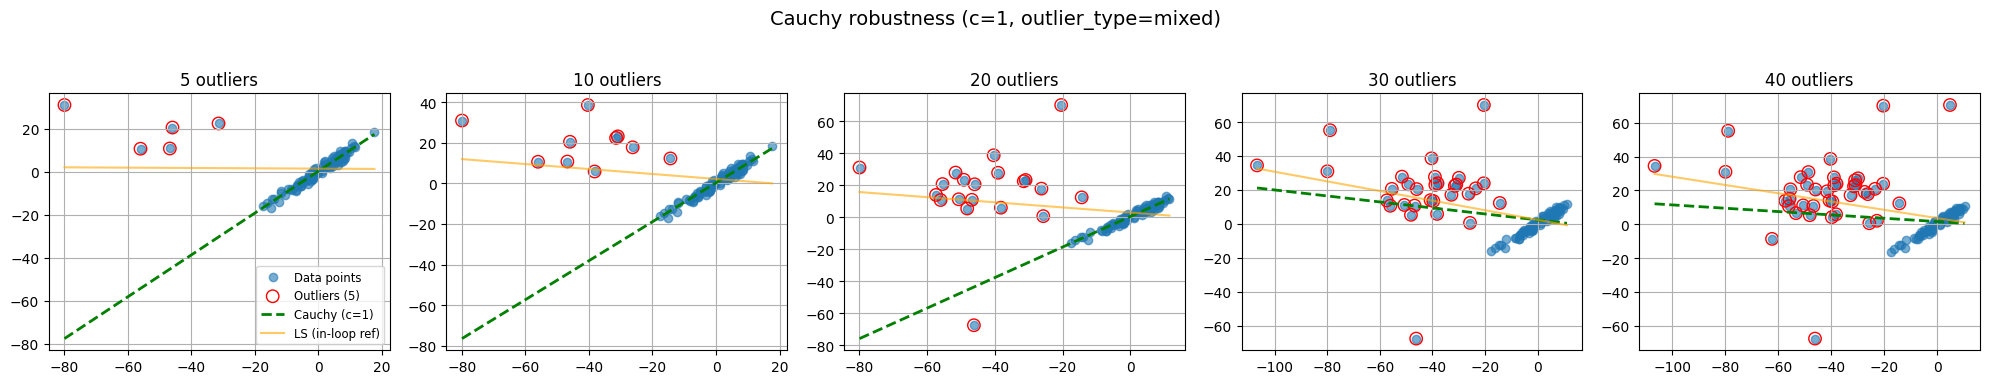

Cauchy parameter c = 0.01
Outliers =  5 | LS: w0=-0.0075, w1=1.4157, RMSE_inliers=7.260
                 Cauchy(c=0.01): w0=-0.0007, w1=0.0040, RMSE_inliers=7.173
Outliers = 10 | LS: w0=-0.1224, w1=2.1912, RMSE_inliers=8.175
                 Cauchy(c=0.01): w0=0.0068, w1=-0.0002, RMSE_inliers=7.196
Outliers = 20 | LS: w0=-0.1602, w1=2.8362, RMSE_inliers=8.100
                 Cauchy(c=0.01): w0=-0.0016, w1=0.0003, RMSE_inliers=6.947
Outliers = 30 | LS: w0=-0.2834, w1=2.3847, RMSE_inliers=9.019
                 Cauchy(c=0.01): w0=-0.0050, w1=0.0004, RMSE_inliers=6.932
Outliers = 40 | LS: w0=-0.2450, w1=3.5847, RMSE_inliers=9.361
                 Cauchy(c=0.01): w0=-0.0103, w1=0.0006, RMSE_inliers=7.084


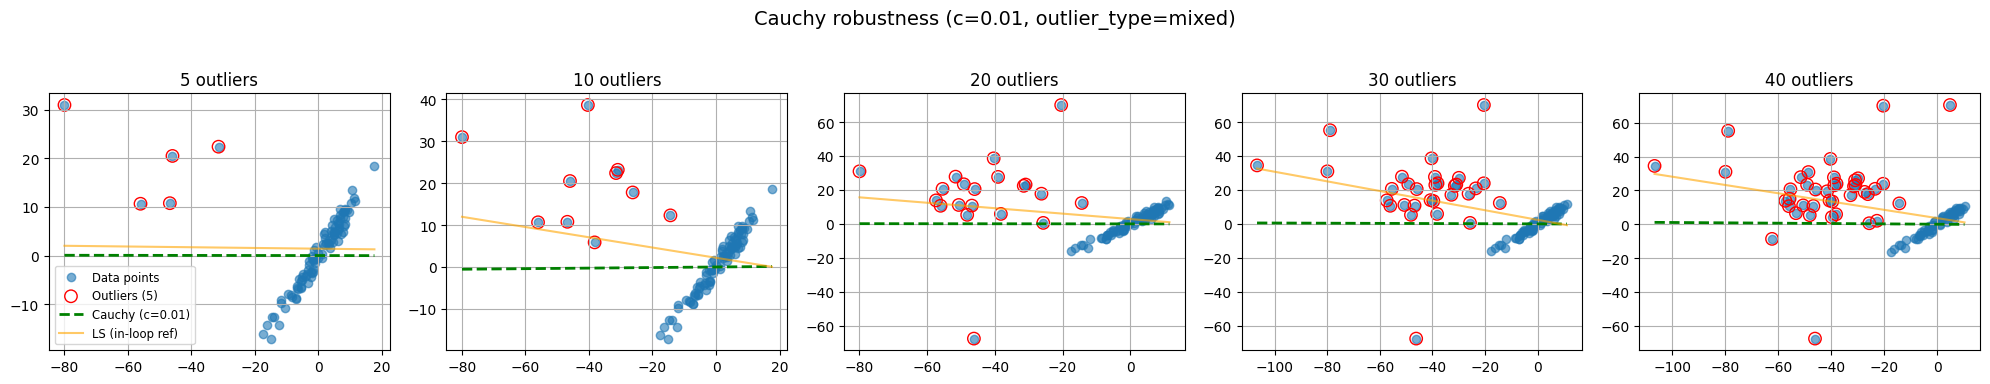

In [54]:
###  EX 6 TYPE OF NOISE 2 ###

import numpy as np
import matplotlib.pyplot as plt

def run_cauchy_outlier_experiment(
    outlier_counts=(5, 10, 20, 30, 40), 
    c_values=(1, 1/100),
    outlier_type="mixed",   # "gaussian", "uniform", "laplace", "cauchy", or "mixed"
    base_angle=45,
    seed=0
):
    """
    Experiment showing robustness of Cauchy loss under different types of outlier noise.
    """

    np.random.seed(seed)

    def rmse(y_true, y_pred):
        return np.sqrt(np.mean((y_true - y_pred)**2))

    base_points = generate_points(angle_deg=base_angle, seed=seed)
    w_ls_clean, b_ls_clean = gradient_descent(base_points, return_residuals=False)
    print(f"Baseline (clean data) LS: w0={w_ls_clean:.4f}, w1={b_ls_clean:.4f}\n")

    for c in c_values:
        print("===========================================")
        print(f"Cauchy parameter c = {c}")
        print("===========================================")

        n_cases = len(outlier_counts)
        fig, axes = plt.subplots(1, n_cases, figsize=(4 * n_cases, 4), squeeze=False)

        for idx, n_outliers in enumerate(outlier_counts):
            # regenerate clean dataset
            points = generate_points(angle_deg=base_angle, seed=seed).copy()

            # create noisy outliers depending on the chosen distribution
            n_out = min(n_outliers, len(points))
            if n_out > 0:
                if outlier_type == "gaussian":
                    noise_x = np.random.normal(-40, 10, size=n_out)
                    noise_y = np.random.normal(20, 10, size=n_out)
                elif outlier_type == "uniform":
                    noise_x = np.random.uniform(-60, -20, size=n_out)
                    noise_y = np.random.uniform(10, 50, size=n_out)
                elif outlier_type == "laplace":
                    noise_x = np.random.laplace(-40, 10, size=n_out)
                    noise_y = np.random.laplace(20, 10, size=n_out)
                elif outlier_type == "cauchy":
                    noise_x = np.random.standard_cauchy(size=n_out) * 15 - 40
                    noise_y = np.random.standard_cauchy(size=n_out) * 15 + 20
                elif outlier_type == "mixed":
                    # randomly pick a type per outlier
                    noise_x = np.zeros(n_out)
                    noise_y = np.zeros(n_out)
                    for j in range(n_out):
                        t = np.random.choice(["gaussian", "uniform", "laplace", "cauchy"])
                        if t == "gaussian":
                            noise_x[j] = np.random.normal(-40, 10)
                            noise_y[j] = np.random.normal(20, 10)
                        elif t == "uniform":
                            noise_x[j] = np.random.uniform(-60, -20)
                            noise_y[j] = np.random.uniform(10, 50)
                        elif t == "laplace":
                            noise_x[j] = np.random.laplace(-40, 10)
                            noise_y[j] = np.random.laplace(20, 10)
                        else:
                            noise_x[j] = np.random.standard_cauchy() * 15 - 40
                            noise_y[j] = np.random.standard_cauchy() * 15 + 20
                else:
                    raise ValueError(f"Unknown outlier_type: {outlier_type}")

                # apply outliers
                points[:n_out, 0] = noise_x
                points[:n_out, 1] = noise_y

            # indices of outliers
            outlier_idx = np.arange(n_out)

            # Fit both models
            w_ls, b_ls, u_ls = ls_closed_form(points)
            w_c, b_c, u_c = gradient_descent_robust(points, c=c, return_residuals=True)

            # Compute metrics
            x = points[:, 0]
            y = points[:, 1]
            ypred_ls = w_ls * x + b_ls
            ypred_c = w_c * x + b_c

            rmse_all_ls = rmse(y, ypred_ls)
            rmse_all_c = rmse(y, ypred_c)

            inlier_idx = np.arange(n_out, len(points))
            if len(inlier_idx) > 0:
                rmse_inliers_ls = rmse(y[inlier_idx], ypred_ls[inlier_idx])
                rmse_inliers_c = rmse(y[inlier_idx], ypred_c[inlier_idx])
            else:
                rmse_inliers_ls = rmse_inliers_c = np.nan

            print(f"Outliers = {n_out:2d} | LS: w0={w_ls:.4f}, w1={b_ls:.4f}, RMSE_inliers={rmse_inliers_ls:.3f}")
            print(f"                 Cauchy(c={c}): w0={w_c:.4f}, w1={b_c:.4f}, RMSE_inliers={rmse_inliers_c:.3f}")

            # Plot
            ax = axes[0, idx]
            ax.scatter(x, y, color='tab:blue', alpha=0.6, label='Data points')
            if n_out > 0:
                ax.scatter(points[outlier_idx, 0], points[outlier_idx, 1],
                           facecolors='none', edgecolors='red', s=80, label=f'Outliers ({n_out})')

            sort_idx = np.argsort(x)
            x_sorted = x[sort_idx]
            ax.plot(x_sorted, w_c * x_sorted + b_c, color='green', lw=2, ls='--', label=f'Cauchy (c={c})')
            ax.plot(x_sorted, w_ls * x_sorted + b_ls, color='orange', linewidth=1.5, alpha=0.6, label='LS (in-loop ref)')

            if idx == 0:
                ax.legend(fontsize='small')
            ax.set_title(f"{n_out} outliers")
            ax.grid(True)

        plt.suptitle(f"Cauchy robustness (c={c}, outlier_type={outlier_type})", fontsize=14)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()


# Example usage:
run_cauchy_outlier_experiment(outlier_type="mixed")


Baseline (clean) LS: w0=0.9851, w1=0.2005

Cauchy parameter c = 1
Outliers= 5 | LS: w0=0.8840, w1=0.7264, RMSE_inliers=1.677
                 Cauchy(c=1): w0=0.9743, w1=0.2940, RMSE_inliers=1.433
Outliers=10 | LS: w0=0.8858, w1=0.8472, RMSE_inliers=1.715
                 Cauchy(c=1): w0=0.9606, w1=0.3471, RMSE_inliers=1.461
Outliers=20 | LS: w0=0.6688, w1=0.9786, RMSE_inliers=2.622
                 Cauchy(c=1): w0=0.9551, w1=0.3204, RMSE_inliers=1.449
Outliers=40 | LS: w0=0.5048, w1=0.2864, RMSE_inliers=3.643
                 Cauchy(c=1): w0=0.9363, w1=0.5356, RMSE_inliers=1.521
Outliers=50 | LS: w0=0.4810, w1=0.8456, RMSE_inliers=3.937
                 Cauchy(c=1): w0=0.9215, w1=0.1371, RMSE_inliers=1.540


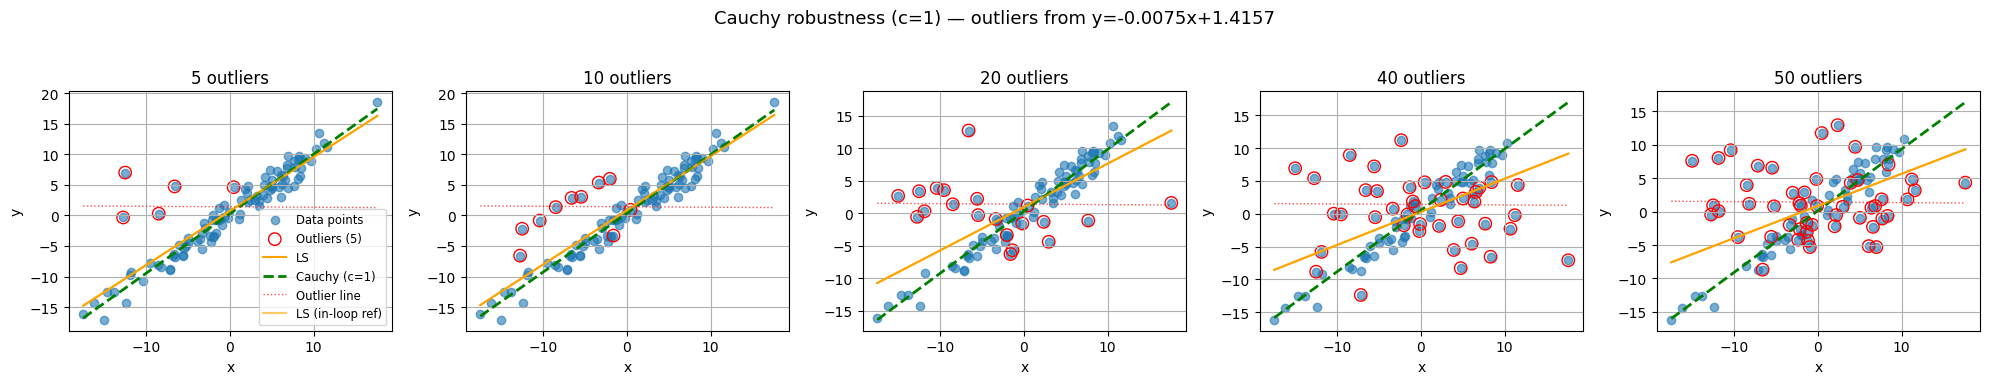

Cauchy parameter c = 0.01
Outliers= 5 | LS: w0=0.8776, w1=0.7377, RMSE_inliers=1.700
                 Cauchy(c=0.01): w0=0.0042, w1=0.0039, RMSE_inliers=7.139
Outliers=10 | LS: w0=0.8672, w1=0.7634, RMSE_inliers=1.745
                 Cauchy(c=0.01): w0=0.0098, w1=-0.0003, RMSE_inliers=7.175
Outliers=20 | LS: w0=0.6669, w1=0.8820, RMSE_inliers=2.616
                 Cauchy(c=0.01): w0=0.0066, w1=0.0018, RMSE_inliers=6.892
Outliers=40 | LS: w0=0.4812, w1=0.4634, RMSE_inliers=3.799
                 Cauchy(c=0.01): w0=-0.0147, w1=0.0014, RMSE_inliers=7.114
Outliers=50 | LS: w0=0.4326, w1=0.8047, RMSE_inliers=4.253
                 Cauchy(c=0.01): w0=0.0013, w1=0.0017, RMSE_inliers=7.213


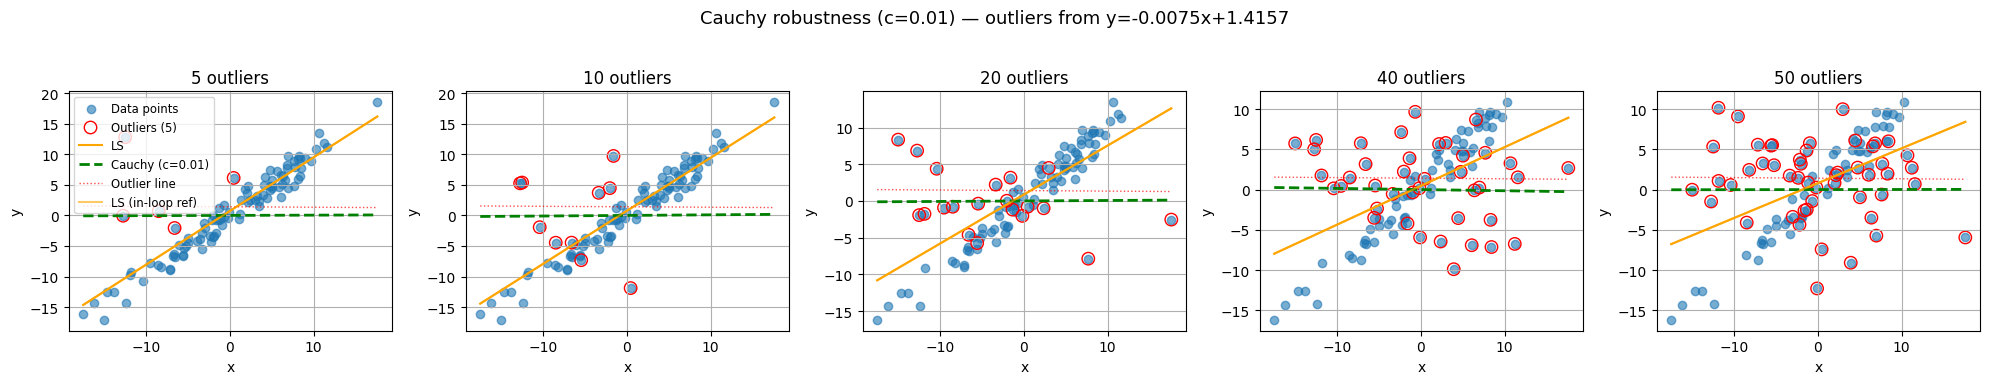

In [59]:
import numpy as np
import matplotlib.pyplot as plt

def run_cauchy_outlier_experiment_v2(
    outlier_counts=(5, 10, 20, 40, 50), 
    c_values=(1, 1/100),
    w0_outlier=-0.0075,
    w1_outlier=1.4157,
    outlier_sigma=5,
    seed=0
):
    """
    Test robustness of the Cauchy estimator by adding outliers generated from a different line.
    Inliers come from the original generate_points(angle_deg=45, seed=0) dataset.
    Outliers are generated according to y = w0_outlier * x + w1_outlier + noise.
    """
    np.random.seed(seed)

    def rmse(y_true, y_pred):
        return np.sqrt(np.mean((y_true - y_pred)**2))

    # === Load base clean dataset (45° line, small noise) ===
    base_points = generate_points(angle_deg=45, seed=seed)
    n_total = len(base_points)

    # === Compute LS baseline on clean data ===
    w_ls_clean, b_ls_clean = gradient_descent(base_points, return_residuals=False)
    print(f"Baseline (clean) LS: w0={w_ls_clean:.4f}, w1={b_ls_clean:.4f}\n")

    # === Iterate over c values ===
    for c in c_values:
        print("===========================================")
        print(f"Cauchy parameter c = {c}")
        print("===========================================")

        n_cases = len(outlier_counts)
        fig, axes = plt.subplots(1, n_cases, figsize=(4 * n_cases, 4), squeeze=False)

        for idx, n_outliers in enumerate(outlier_counts):
            # Copy clean dataset
            points = base_points.copy()

            # Choose first n_outliers as outliers (or random subset)
            outlier_idx = np.arange(min(n_outliers, n_total))

            # Replace those y-values with points generated from the "outlier line"
            x_outliers = points[outlier_idx, 0]
            y_outliers = w0_outlier * x_outliers + w1_outlier + np.random.normal(0, outlier_sigma, len(x_outliers))
            points[outlier_idx, 1] = y_outliers

            # Fit both regressions
            w_ls, b_ls, u_ls = gradient_descent(points, return_residuals=True)
            w_c, b_c, u_c = gradient_descent_robust(points, c=c, return_residuals=True)

            # Compute RMSEs
            x = points[:, 0]
            y = points[:, 1]
            ypred_ls = w_ls * x + b_ls
            ypred_c = w_c * x + b_c
            rmse_all_ls = rmse(y, ypred_ls)
            rmse_all_c = rmse(y, ypred_c)

            # Compute inlier-only RMSE
            inlier_mask = np.ones(len(points), dtype=bool)
            inlier_mask[outlier_idx] = False
            rmse_inliers_ls = rmse(y[inlier_mask], ypred_ls[inlier_mask])
            rmse_inliers_c = rmse(y[inlier_mask], ypred_c[inlier_mask])

            # Print summary
            print(f"Outliers={n_outliers:2d} | LS: w0={w_ls:.4f}, w1={b_ls:.4f}, RMSE_inliers={rmse_inliers_ls:.3f}")
            print(f"                 Cauchy(c={c}): w0={w_c:.4f}, w1={b_c:.4f}, RMSE_inliers={rmse_inliers_c:.3f}")

            # === Plot ===
            ax = axes[0, idx]
            ax.scatter(x, y, color='tab:blue', alpha=0.6, label='Data points')
            if n_outliers > 0:
                ax.scatter(points[outlier_idx, 0], points[outlier_idx, 1],
                           facecolors='none', edgecolors='red', s=80, label=f'Outliers ({n_outliers})')

            sort_idx = np.argsort(x)
            x_sorted = x[sort_idx]
            ax.plot(x_sorted, w_ls * x_sorted + b_ls, color='orange', lw=1.5, label='LS')
            ax.plot(x_sorted, w_c * x_sorted + b_c, color='green', lw=2, ls='--', label=f'Cauchy (c={c})')

            # Add reference outlier line
            ax.plot(x_sorted, w0_outlier * x_sorted + w1_outlier, color='red', lw=1, ls=':', alpha=0.7, label='Outlier line')
            ax.plot(x_sorted, w_ls * x_sorted + b_ls, color='orange', linewidth=1.5, alpha=0.6, label='LS (in-loop ref)')

            

            ax.set_title(f"{n_outliers} outliers")
            ax.set_xlabel('x')
            ax.set_ylabel('y')
            ax.grid(True)
            if idx == 0:
                ax.legend(fontsize='small')

        plt.suptitle(f"Cauchy robustness (c={c}) — outliers from y={w0_outlier}x+{w1_outlier}", fontsize=13)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()


# Run the experiment
run_cauchy_outlier_experiment_v2()

The experiment perturbs the clean linear dataset with an increasing number of outliers drawn from a second line with a different slope and intercept. When $c=1$, the Cauchy estimator behaves robustly at low contamination: with 5–10 outliers the fitted line remains close to the inlier trend and improves over least squares in terms of inlier RMSE. As the number of outliers grows to 20, the influence of the contaminating line becomes visible: both estimators begin to drift toward the secondary trend, and the gap between LS and Cauchy shrinks. At 40–50 outliers, the contamination constitutes a large proportion of the dataset; both LS and Cauchy converge toward the contaminant direction, and Cauchy’s downweighting is no longer sufficient to resist the collective pull of the outlier structure. This confirms that Cauchy robustness is effective only as long as the proportion of outliers remains moderate and they are not too structurally coherent.

For c=0.01, the estimator is considerably more aggressive in suppressing the influence of outliers. Across 5–20 outliers the Cauchy fit remains essentially stable and anchored to the inlier trend, while the LS solution shifts progressively toward the contaminant line. The inlier RMSE under Cauchy remains nearly constant, whereas LS deteriorates rapidly. However, at 40–50 outliers, even this strongly downweighting version begins to show signs of sensitivity. The fitted line is still much closer to the true inlier structure than LS, but the influence of the contaminant cluster becomes noticeable. This illustrates that even a very small c cannot guarantee immunity when contamination dominates the dataset numerically and structurally.


As the number of outliers increases, the performance of the Cauchy-based linear regression deteriorates progressively. While the Cauchy loss successfully downweights individual extreme points when they are relatively few, it is not designed to withstand arbitrarily large contamination levels. The robustness it provides is local: it protects against isolated, sparse or weak outliers, but it cannot prevent systematic drift once a large portion of the data is misaligned.

When only a small number of outliers is introduced, their influence remains limited, and the Cauchy fit stays close to the true inlier trend. The residual distribution in this regime is dominated by genuine inliers, and the downweighting mechanism is sufficient to neutralize the handful of corrupted observations.

However, as the proportion of outliers grows, the situation changes qualitatively. Outliers begin to form a coherent structure—often following their own linear pattern—and the estimator effectively sees two competing trends. Because Cauchy loss down-weights large residuals but does not discard them entirely, the accumulated effect of many moderately influential outliers biases the objective function. Their aggregate contribution becomes strong enough that the fitted line gradually shifts toward the contaminating direction.

At high contamination levels, the outliers collectively dominate the loss, even when c is small. The Cauchy estimator, although more robust than least squares, is no longer able to isolate the inlier pattern, and the regression line fails to represent the underlying structure. This demonstrates that Cauchy’s robustness is conditional and not absolute: it provides good protection against a limited number of outliers but does not remain reliable when the contamination ratio becomes large or highly structured.

In summary, the experiments confirm that while Cauchy regression improves stability compared to least squares, especially at moderate contamination levels, it loses effectiveness as the number of outliers increases, and therefore its robustness should not be interpreted as universal or unlimited.
